In [11]:
import pandas as pd

dfs = {}
for f, key in [('merged_2022_all.csv', '2022'), ('merged_2024_all.csv', '2024'), ('merged_2026.csv', '2026')]:
    dfs[key] = pd.read_csv(f'../cleaned_dataset/updated/{f}', encoding='utf-16', on_bad_lines='skip')
    print(f'\n--- {key} ---')
    print(dfs[key].shape)
    print(dfs[key].columns.tolist())


--- 2022 ---
(5881, 15)
['year', 'platform', 'handle', 'name', 'rank', 'followers', 'audience_country', 'category_unified', 'er_pct', 'engagement_avg', 'likes_avg', 'comments_avg', 'views_avg', 'shares_avg', 'number_videos_last_year']

--- 2024 ---
(16386, 17)
['year', 'platform', 'month', 'handle', 'name', 'rank', 'followers', 'audience_country', 'category_unified', 'er_pct', 'engagement_avg', 'likes_avg', 'comments_avg', 'views_avg', 'shares_avg', 'potential_reach', 'number_videos_last_year']

--- 2026 ---
(583, 17)
['year', 'platform', 'month', 'handle', 'name', 'rank', 'followers', 'audience_country', 'category_unified', 'er_pct', 'engagement_avg', 'likes_avg', 'comments_avg', 'views_avg', 'shares_avg', 'potential_reach', 'number_videos_last_year']


In [9]:
import pandas as pd

for f in ['merged_2022_all.csv', 'merged_2024_all.csv', 'merged_2026.csv']:
    df = pd.read_csv(f'../cleaned_dataset/updated/{f}', encoding='utf-16')
    print(f'\n--- {f} ---')
    print(df.shape)
    print(df.columns.tolist())


--- merged_2022_all.csv ---
(5881, 15)
['year', 'platform', 'handle', 'name', 'rank', 'followers', 'audience_country', 'category_unified', 'er_pct', 'engagement_avg', 'likes_avg', 'comments_avg', 'views_avg', 'shares_avg', 'number_videos_last_year']


ParserError: Error tokenizing data. C error: Expected 17 fields in line 458, saw 18


In [12]:
for key, df in dfs.items():
    print(f'\n--- {key} ---')
    print(df['platform'].value_counts())


--- 2022 ---
platform
TikTok       3060
Instagram    1463
YouTube      1358
Name: count, dtype: int64

--- 2024 ---
platform
TikTok       5781
YouTube      5664
Instagram    4941
Name: count, dtype: int64

--- 2026 ---
platform
YouTube    583
Name: count, dtype: int64


In [6]:
import os
print(os.getcwd())

c:\Users\user\cross_platform_analysis\Exploratory data analysis


In [7]:
import os
os.chdir("..")
print(os.getcwd())
print(os.listdir("cleaned_dataset/updated"))

c:\Users\user\cross_platform_analysis
['0412.md', 'merged_2022_all.csv', 'merged_2024_all.csv', 'merged_2026.csv']


In [9]:
import pandas as pd

df_2022 = pd.read_csv("cleaned_dataset/updated/merged_2022_all.csv", encoding='utf-16')
print(df_2022.shape)
print(df_2022.columns.tolist())

(5881, 15)
['year', 'platform', 'handle', 'name', 'rank', 'followers', 'audience_country', 'category_unified', 'er_pct', 'engagement_avg', 'likes_avg', 'comments_avg', 'views_avg', 'shares_avg', 'number_videos_last_year']


In [11]:
df_2024 = pd.read_csv("cleaned_dataset/updated/merged_2024_all.csv", encoding='utf-16', on_bad_lines='skip')
df_2026 = pd.read_csv("cleaned_dataset/updated/merged_2026.csv", encoding='utf-16', on_bad_lines='skip')

print("2022:", df_2022.shape)
print("2024:", df_2024.shape, df_2024.columns.tolist())
print("2026:", df_2026.shape, df_2026.columns.tolist())

2022: (5881, 15)
2024: (16386, 17) ['year', 'platform', 'month', 'handle', 'name', 'rank', 'followers', 'audience_country', 'category_unified', 'er_pct', 'engagement_avg', 'likes_avg', 'comments_avg', 'views_avg', 'shares_avg', 'potential_reach', 'number_videos_last_year']
2026: (583, 17) ['year', 'platform', 'month', 'handle', 'name', 'rank', 'followers', 'audience_country', 'category_unified', 'er_pct', 'engagement_avg', 'likes_avg', 'comments_avg', 'views_avg', 'shares_avg', 'potential_reach', 'number_videos_last_year']


In [12]:
print("=== 2022 ===")
print(df_2022[['platform', 'followers', 'er_pct']].dtypes)
print(df_2022['platform'].unique())
print(df_2022['er_pct'].describe())

print("\n=== 2024 ===")
print(df_2024[['platform', 'followers', 'er_pct']].dtypes)
print(df_2024['platform'].unique())
print(df_2024['er_pct'].describe())

=== 2022 ===
platform         str
followers        str
er_pct       float64
dtype: object
<StringArray>
['Instagram', 'TikTok', 'YouTube']
Length: 3, dtype: str
count    5.875000e+03
mean     1.577217e+04
std      2.030840e+05
min      0.000000e+00
25%      1.122843e+00
50%      5.555357e+00
75%      1.736493e+01
max      1.090000e+07
Name: er_pct, dtype: float64

=== 2024 ===
platform         str
followers        str
er_pct       float64
dtype: object
<StringArray>
['Instagram', 'YouTube', 'TikTok']
Length: 3, dtype: str
count    8254.000000
mean        1.947514
std         4.261638
min         0.010000
25%         0.210000
50%         0.700000
75%         2.000000
max       121.000000
Name: er_pct, dtype: float64


In [13]:
import numpy as np

def convert_to_number(val):
    if isinstance(val, str):
        val = val.strip().replace(',', '')
        if val.endswith('M'):
            return round(float(val[:-1]) * 1_000_000)
        elif val.endswith('K'):
            return round(float(val[:-1]) * 1_000)
        elif val.endswith('B'):
            return round(float(val[:-1]) * 1_000_000_000)
    try:
        return round(float(val))
    except:
        return np.nan

df_2022['followers'] = df_2022['followers'].apply(convert_to_number)
df_2024['followers'] = df_2024['followers'].apply(convert_to_number)

# check er_pct outliers in 2022
print(df_2022[df_2022['er_pct'] > 100][['platform', 'name', 'followers', 'er_pct']].head(10))

      platform                          name  followers      er_pct
0    Instagram                   ?뉌뀫?ⓤ꼳?듄꼺??        NaN    872600.0
12   Instagram                 ??듄넽?뗡뀸?뉌뀿??        NaN    597300.0
50   Instagram             SUGA of BTS 誘쇱쑄湲?        NaN  10900000.0
118  Instagram       ?쏳EAL HASTA LA MUERTE??        NaN    892100.0
203  Instagram        Yassine Bounou ?쏝ONO??        NaN    643100.0
226  Instagram               BY PAMELLA ?⑩윧?        NaN    406800.0
263  Instagram            Chiara Ferragni ??        NaN    616600.0
280  Instagram                 ??듄넽?됣뀰?뚡뀯??        NaN   2000000.0
308  Instagram  DARIAN R. C R A W S T O N ??        NaN    827500.0
409  Instagram                         諛뺤?鍮?        NaN    814700.0


In [14]:
import numpy as np

def convert_to_number(val):
    if isinstance(val, str):
        val = val.strip().replace(',', '')
        if val.endswith('M'):
            return round(float(val[:-1]) * 1_000_000)
        elif val.endswith('K'):
            return round(float(val[:-1]) * 1_000)
        elif val.endswith('B'):
            return round(float(val[:-1]) * 1_000_000_000)
    try:
        return round(float(val))
    except:
        return np.nan

df_2022['followers'] = df_2022['followers'].apply(convert_to_number)
df_2024['followers'] = df_2024['followers'].apply(convert_to_number)

# check er_pct outliers in 2022
print(df_2022[df_2022['er_pct'] > 100][['platform', 'name', 'followers', 'er_pct']].head(10))

      platform                          name  followers      er_pct
0    Instagram                   ?뉌뀫?ⓤ꼳?듄꼺??        NaN    872600.0
12   Instagram                 ??듄넽?뗡뀸?뉌뀿??        NaN    597300.0
50   Instagram             SUGA of BTS 誘쇱쑄湲?        NaN  10900000.0
118  Instagram       ?쏳EAL HASTA LA MUERTE??        NaN    892100.0
203  Instagram        Yassine Bounou ?쏝ONO??        NaN    643100.0
226  Instagram               BY PAMELLA ?⑩윧?        NaN    406800.0
263  Instagram            Chiara Ferragni ??        NaN    616600.0
280  Instagram                 ??듄넽?됣뀰?뚡뀯??        NaN   2000000.0
308  Instagram  DARIAN R. C R A W S T O N ??        NaN    827500.0
409  Instagram                         諛뺤?鍮?        NaN    814700.0


In [15]:
print("2022 rows with er_pct > 100:", (df_2022['er_pct'] > 100).sum())
print("2022 rows with NaN followers:", df_2022['followers'].isna().sum())

2022 rows with er_pct > 100: 425
2022 rows with NaN followers: 144


In [13]:
for key in ['2022', '2024']:
    print(f'\n--- {key} ---')
    print(dfs[key].isnull().sum())


--- 2022 ---
year                          0
platform                      0
handle                        0
name                         27
rank                       5739
followers                    89
audience_country           3264
category_unified           3429
er_pct                        6
engagement_avg             1400
likes_avg                  1465
comments_avg               1484
views_avg                  1472
shares_avg                 2906
number_videos_last_year    5881
dtype: int64

--- 2024 ---
year                           0
platform                       0
month                      16386
handle                      2019
name                          60
rank                       15910
followers                     54
audience_country             421
category_unified            9084
er_pct                      8132
engagement_avg             16386
likes_avg                  16386
comments_avg               16386
views_avg                  16386
shares_avg       

In [14]:
print(dfs['2024'][['platform', 'followers', 'er_pct', 'engagement_avg', 'likes_avg', 'category_unified']].head(10))

    platform   followers  er_pct  engagement_avg  likes_avg category_unified
0  Instagram  63900000.0    1.27             NaN        NaN            Music
1  Instagram  56400000.0    0.96             NaN        NaN            Music
2  Instagram  54300000.0    0.21             NaN        NaN   Beauty&Fashion
3  Instagram  54600000.0    0.03             NaN        NaN            Music
4  Instagram  55300000.0    0.27             NaN        NaN   Beauty&Fashion
5  Instagram  55500000.0    0.87             NaN        NaN   Beauty&Fashion
6  Instagram  55700000.0    0.02             NaN        NaN   Beauty&Fashion
7  Instagram  55900000.0    4.14             NaN        NaN            Music
8  Instagram  56400000.0    0.90             NaN        NaN           Sports
9  Instagram  56800000.0    0.02             NaN        NaN   Beauty&Fashion


In [15]:
for key in ['2022', '2024']:
    print(f'\n--- {key} ---')
    print(dfs[key].groupby('platform')['category_unified'].value_counts())


--- 2022 ---
platform   category_unified  
Instagram  Entertainment         371
           Music                 321
           Lifestyle             276
           Sports                195
           Beauty&Fashion        109
                                ... 
YouTube    0.2346923076923076      1
           0.0058129496402877      1
           0.0052774193548387      1
           0.4384615384615384      1
           0.0087894736842105      1
Name: count, Length: 156, dtype: int64

--- 2024 ---
platform   category_unified
Instagram  Beauty&Fashion      1215
           Music                896
           Sports               770
           Knowledge&Info       492
           Entertainment        400
                               ... 
YouTube    1.4                    2
           1.3                    1
           2.5                    1
           2.1                    1
           0.7                    1
Name: count, Length: 180, dtype: int64


In [16]:
yt = dfs['2022'][dfs['2022']['platform'] == 'YouTube']
print(yt[['name', 'followers', 'audience_country', 'category_unified', 'er_pct']].head(10))

                       name   followers audience_country    category_unified  \
4523        #Refugio Mental  14200000.0        Argentina       Entertainment   
4524        #Ref첬gio Mental  12800000.0           Brazil       Entertainment   
4525  ??걯?곥걮?껁걾?뉎꺖竊늜ajime竊?       Japan            Music  0.4384615384615384   
4526                   TKOR  12700000.0    United States           Lifestyle   
4527                123 GO!  12100000.0    United States           Lifestyle   
4528          123 GO! Hindi  10200000.0            India                 NaN   
4529        123 GO! Spanish  13500000.0           Mexico       Entertainment   
4530  1MILLION Dance Studio  25700000.0            India                 NaN   
4531             Veritasium  12800000.0    United States         Tech&Gaming   
4532        5-Minute Crafts  77900000.0            India                 NaN   

        er_pct  
4523  0.058333  
4524  0.081787  
4525       NaN  
4526  0.031937  
4527  0.054802  
4528  0.066417  


In [17]:
yt = dfs['2022'][dfs['2022']['platform'] == 'YouTube']
# numeric values in category_unified indicate shifted rows
shifted = yt['category_unified'].apply(lambda x: str(x).replace('.','').replace('-','').isnumeric() if pd.notna(x) else False)
print(f"Shifted rows: {shifted.sum()} / {len(yt)}")
print(yt[shifted][['name', 'category_unified', 'er_pct']].head(10))

Shifted rows: 5 / 1358
                       name    category_unified  er_pct
4525  ??걯?곥걮?껁걾?뉎꺖竊늜ajime竊?  0.4384615384615384     NaN
4838     GMMTV OFFICIAL?뗢?  0.0058129496402877     NaN
4923            ATHLEAN-X??  0.2346923076923076     NaN
5621     GMMTV OFFICIAL?뗢?  0.0052774193548387     NaN
5765          Sagawa /?뺛걣??  0.0087894736842105     NaN


In [18]:
def is_shifted(x):
    try:
        float(x)
        return True
    except:
        return False

mask = (dfs['2022']['platform'] == 'YouTube') & (dfs['2022']['category_unified'].apply(lambda x: is_shifted(x) if pd.notna(x) else False))
print(f"Dropping {mask.sum()} rows")
dfs['2022'] = dfs['2022'][~mask].reset_index(drop=True)
print(f"2022 shape after drop: {dfs['2022'].shape}")

Dropping 5 rows
2022 shape after drop: (5876, 15)


In [19]:
# undo the drop first
dfs['2022'] = pd.read_csv('../cleaned_dataset/updated/merged_2022_all.csv', encoding='utf-16')

mask = (dfs['2022']['platform'] == 'YouTube') & (dfs['2022']['category_unified'].apply(lambda x: is_shifted(x) if pd.notna(x) else False))

dfs['2022'].loc[mask, 'er_pct'] = dfs['2022'].loc[mask, 'category_unified'].astype(float)
dfs['2022'].loc[mask, 'category_unified'] = None

print(f"Fixed {mask.sum()} rows")
print(dfs['2022'][mask][['name', 'category_unified', 'er_pct']].head())

Fixed 5 rows
                       name category_unified    er_pct
4525  ??걯?곥걮?껁걾?뉎꺖竊늜ajime竊?              NaN  0.438462
4838     GMMTV OFFICIAL?뗢?              NaN  0.005813
4923            ATHLEAN-X??              NaN  0.234692
5621     GMMTV OFFICIAL?뗢?              NaN  0.005277
5765          Sagawa /?뺛걣??              NaN  0.008789


In [20]:
for key in ['2022', '2024']:
    print(f'\n--- {key} ---')
    print(dfs[key].groupby('platform')['er_pct'].describe().round(4))


--- 2022 ---
            count        mean          std     min     25%      50%      75%  \
platform                                                                       
Instagram  1462.0  44191.9612  386364.9775  0.0339  1.9395   4.7867  10.8168   
TikTok     3060.0   9143.6579   85787.0631  0.3173  5.1832  12.4958  32.6250   
YouTube    1358.0     53.9489    1924.3493  0.0000  0.0098   0.0612   0.3798   

                  max  
platform               
Instagram  10900000.0  
TikTok      3538800.0  
YouTube       70900.0  

--- 2024 ---
            count    mean     std   min     25%   50%     75%     max
platform                                                             
Instagram  4726.0  2.2832  4.1482  0.01  0.3825  1.05  2.5775  115.81
TikTok     1377.0  1.1391  4.4473  0.10  0.1000  0.20  0.6000  121.00
YouTube    2151.0  1.7275  4.3040  0.10  0.2000  0.50  1.5000   80.10


In [21]:
ig22 = dfs['2022'][dfs['2022']['platform'] == 'Instagram']
print(ig22[['name', 'followers', 'engagement_avg', 'er_pct']].head(10))

                  name    followers  engagement_avg         er_pct
0          ?뉌뀫?ⓤ꼳?듄꼺??  South Korea             NaN  872600.000000
1                  NaN   14700000.0        475800.0       3.524444
2               Ars ?럸    6700000.0        431600.0       6.580000
3      Sakura Miyawaki    4300000.0       1100000.0      25.581395
4        Gerard Pique?   20400000.0        668800.0       3.327273
5                  433   58200000.0        672100.0       1.313402
6      5-Minute Crafts   46200000.0         78400.0       0.169697
7              50 Cent   27900000.0        283200.0       1.015054
8  5 Seconds of Summer   10100000.0        213700.0       2.115842
9                  NaN   21600000.0       1900000.0       8.796296


In [22]:
for platform in ['Instagram', 'TikTok', 'YouTube']:
    df = dfs['2022'][dfs['2022']['platform'] == platform]
    bad = (df['er_pct'] > 100).sum()
    print(f"{platform}: {bad} rows with er_pct > 100 out of {len(df)}")

Instagram: 52 rows with er_pct > 100 out of 1463
TikTok: 370 rows with er_pct > 100 out of 3060
YouTube: 3 rows with er_pct > 100 out of 1358


In [23]:
tt22 = dfs['2022'][dfs['2022']['platform'] == 'TikTok']
print(tt22[['likes_avg', 'comments_avg', 'followers']].isnull().sum())
print(f"Total TikTok rows: {len(tt22)}")

likes_avg        0
comments_avg     0
followers       85
dtype: int64
Total TikTok rows: 3060


In [24]:
df22 = dfs['2022'].copy()

for platform in ['Instagram', 'TikTok', 'YouTube']:
    sub = df22[(df22['platform'] == platform) & (df22['er_pct'] <= 100)]
    print(f"\n{platform} (n={len(sub)})")
    print(sub['er_pct'].describe().round(4))


Instagram (n=1410)
count    1410.0000
mean        7.6168
std         8.6068
min         0.0339
25%         1.8476
50%         4.4541
75%         9.9291
max        77.7778
Name: er_pct, dtype: float64

TikTok (n=2690)
count    2690.0000
mean       17.1256
std        18.8860
min         0.3173
25%         4.7076
50%        10.2598
75%        21.3886
max        99.2196
Name: er_pct, dtype: float64

YouTube (n=1355)
count    1355.0000
mean        0.5274
std         1.8171
min         0.0000
25%         0.0098
50%         0.0612
75%         0.3723
max        45.1420
Name: er_pct, dtype: float64


In [25]:
tt_bad = df22[(df22['platform'] == 'TikTok') & (df22['er_pct'] > 100)]
print(tt_bad[['name', 'followers', 'engagement_avg', 'er_pct']].head(10))

                          name followers  engagement_avg         er_pct
1466              Why Not ? ??       NaN        486400.0  487900.000000
1469    ?ㅿ툘?랅윍Π쎪뫱댭??????ㅿ툘?랅윍?       NaN        210200.0  211900.000000
1470                 劇逵克?棘戟?龜q    5800.0        154800.0    2668.965517
1473                    ?뙵旅쒚윁?       NaN        144700.0  147400.000000
1474  ?뫚?뭳?뭶?뮅?뭳?뮅?뮅?뮅 ?ㅿ툘?랅윍?       NaN        123100.0  123772.000000
1475    晩慢?? 漠碼?魔? 卍?膜 碼???碼??   15000.0         67000.0     446.666667
1481                      goku   74800.0        348100.0     465.374332
1482        ?巒碼痲幕 ?碼漠磨碼邈 ???碼.   13600.0        160700.0    1181.617647
1484                 2nd 岳????       NaN        126800.0  127722.000000
1489               Batu FuRkan   20600.0        173600.0     842.718447


In [26]:
tt22 = df22[df22['platform'] == 'TikTok']
print(f"NaN followers: {tt22['followers'].isna().sum()}")
print(f"er_pct > 100: {(tt22['er_pct'] > 100).sum()}")
print(f"Both: {(tt22['followers'].isna() & (tt22['er_pct'] > 100)).sum()}")

NaN followers: 85
er_pct > 100: 370
Both: 85


In [27]:
tt_bad_valid = tt22[(tt22['followers'].notna()) & (tt22['er_pct'] > 100)]
print(f"Count: {len(tt_bad_valid)}")
print(tt_bad_valid[['name', 'followers', 'engagement_avg', 'er_pct']].head(10))

Count: 285
                        name followers  engagement_avg       er_pct
1470               劇逵克?棘戟?龜q    5800.0        154800.0  2668.965517
1475  晩慢?? 漠碼?魔? 卍?膜 碼???碼??   15000.0         67000.0   446.666667
1481                    goku   74800.0        348100.0   465.374332
1482      ?巒碼痲幕 ?碼漠磨碼邈 ???碼.   13600.0        160700.0  1181.617647
1489             Batu FuRkan   20600.0        173600.0   842.718447
1516               _mrs.grey  127100.0        359400.0   282.769473
1520                   KUWTK   92800.0        433660.0   467.306034
1523      Gh챕t m척n To찼n =)))   87700.0        370800.0   422.805017
1524           _xndi rizlky_   11500.0        168700.0  1466.956522
1526              Nya uwu xd  144300.0        349900.0   242.480942


In [28]:
nan_followers = dfs['2022'][dfs['2022']['followers'].isna()]
print(nan_followers[['name', 'followers', 'audience_country', 'category_unified', 'er_pct']].head(10))

                          name followers audience_country    category_unified  \
1466              Why Not ? ??       NaN              NaN   51.79955409279117   
1469    ?ㅿ툘?랅윍Π쎪뫱댭??????ㅿ툘?랅윍?       NaN              NaN   3162.686567164179   
1473                    ?뙵旅쒚윁?       NaN              NaN              9.2125   
1474  ?뫚?뭳?뭶?뮅?뭳?뮅?뮅?뮅 ?ㅿ툘?랅윍?       NaN              NaN              11.252   
1484                 2nd 岳????       NaN              NaN  33.932518597236985   
1501        NICO?먨뭄?먦깢?⒲깱?녈궡??       NaN              NaN   22.46923076923077   
1507      ??듼쑊?㎮굤 d e s ?㎮굤???       NaN              NaN    641.930817610063   
1539   坊???晩碼痲?馬 碼磨? 万?万? 坊???       NaN              NaN               4.809   
1682                  anggun??       NaN              NaN  1.2114864864864865   
1683                  anggun??       NaN              NaN  0.7462319587628866   

        er_pct  
1466  487900.0  
1469  211900.0  
1473  147400.0  
1474  123772.0  
1484  127722.0  
1501  

In [29]:
df22_clean = dfs['2022'].copy()
df22_clean = df22_clean[df22_clean['followers'].notna()].reset_index(drop=True)

print(df22_clean.groupby('platform').size())
print(f"\nTotal: {len(df22_clean)}")

platform
Instagram    1463
TikTok       2975
YouTube      1354
dtype: int64

Total: 5792


In [30]:
import numpy as np

for platform in ['Instagram', 'TikTok', 'YouTube']:
    sub = df22_clean[df22_clean['platform'] == platform]['followers']
    print(f"\n{platform}")
    print(sub.describe().apply(lambda x: f"{x:,.0f}"))


Instagram


ValueError: Unknown format code 'f' for object of type 'str'

In [31]:
for platform in ['Instagram', 'TikTok', 'YouTube']:
    sub = df22_clean[df22_clean['platform'] == platform]['followers']
    print(f"\n{platform}")
    print(sub.describe().round(0))


Instagram


TypeError: type str doesn't define __round__ method

In [32]:
df22_clean['followers'] = pd.to_numeric(df22_clean['followers'], errors='coerce')

for platform in ['Instagram', 'TikTok', 'YouTube']:
    sub = df22_clean[df22_clean['platform'] == platform]['followers']
    print(f"\n{platform}")
    print(sub.describe())


Instagram
count    1.413000e+03
mean     2.344664e+07
std      4.116212e+07
min      2.200000e+06
25%      8.300000e+06
50%      1.350000e+07
75%      2.330000e+07
max      5.798000e+08
Name: followers, dtype: float64

TikTok
count    2.975000e+03
mean     5.384570e+06
std      8.656557e+06
min      2.100000e+03
25%      1.000000e+06
50%      2.700000e+06
75%      6.200000e+06
max      1.531000e+08
Name: followers, dtype: float64

YouTube
count    1.349000e+03
mean     1.827880e+07
std      1.415203e+07
min      9.200000e+06
25%      1.130000e+07
50%      1.400000e+07
75%      1.960000e+07
max      2.295000e+08
Name: followers, dtype: float64


In [33]:
df24 = dfs['2024'].copy()
df24['followers'] = pd.to_numeric(df24['followers'], errors='coerce')

for platform in ['Instagram', 'TikTok', 'YouTube']:
    sub = df24[df24['platform'] == platform]['followers']
    print(f"\n{platform}")
    print(sub.describe())


Instagram
count    4.789000e+03
mean     7.291064e+06
std      2.496993e+07
min      2.150000e+00
25%      6.919000e+05
50%      2.000000e+06
75%      5.200000e+06
max      6.251000e+08
Name: followers, dtype: float64

TikTok
count    5.483000e+03
mean     2.157409e+06
std      5.873323e+06
min      1.000000e-01
25%      4.334000e+05
50%      8.467000e+05
75%      1.500000e+06
max      1.619000e+08
Name: followers, dtype: float64

YouTube
count    5.585000e+03
mean     4.098494e+06
std      8.590046e+06
min      1.000000e-01
25%      5.030000e+05
50%      1.800000e+06
75%      4.400000e+06
max      2.340000e+08
Name: followers, dtype: float64


In [34]:
for platform in ['Instagram', 'TikTok', 'YouTube']:
    sub = df24[df24['platform'] == platform]
    bad = (sub['followers'] < 1000).sum()
    print(f"{platform}: {bad} rows with followers < 1000")

Instagram: 12 rows with followers < 1000
TikTok: 42 rows with followers < 1000
YouTube: 8 rows with followers < 1000


In [35]:
# Just print all the cell source code without running anything
import json

with open('../data_cleanup_2024.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code':
        print(f"\n--- Cell {i} ---")
        print(''.join(cell['source']))


--- Cell 0 ---
import os
import pandas as pd

for root, dirs, files in os.walk("cleaned_dataset"):
    for file in files:
        print(os.path.join(root, file))

--- Cell 1 ---
for root, dirs, files in os.walk("cleaned_dataset/2024"):
    for file in files:
        print(os.path.join(root, file))

--- Cell 2 ---
df = pd.read_csv("cleaned_dataset/2024/all countries top/2024_instagram_allcountries_unified.csv")
print(df.shape)
print(df.columns.tolist())
print(df.head(3))

--- Cell 3 ---
with open("cleaned_dataset/2024/all countries top/readme.md", "r") as f:
    print(f.read())

--- Cell 4 ---
df = pd.read_csv("cleaned_dataset/2024/all countries top/2024_instagram_allcountries_unified.csv")
print(df.dtypes)
print(df[['followers', 'er', 'potential_reach']].head(5))

--- Cell 5 ---
for folder in ['all countries top', 'separate countries']:
    print(f"\n=== {folder} ===")
    for file in os.listdir(f"cleaned_dataset/2024/{folder}"):
        if file.endswith('.csv'):
            df = pd.r

In [36]:
import pandas as pd

df = pd.read_csv('../cleaned_dataset/2022/instagram_december.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head(3))

(1000, 11)
['rank', 'handle_instagram', 'name_instagram', 'category_1', 'category_2', 'followers', 'audience_country', 'engagement_auth', 'engagement_avg', 'unified_cat_1', 'unified_cat_2']
   rank handle_instagram     name_instagram          category_1 category_2  \
0     1         leomessi          Leo Messi  Sports with a ball     Family   
1     2        cristiano  Cristiano Ronaldo  Sports with a ball        NaN   
2     3         neymarjr              NJ 🇧🇷  Sports with a ball        NaN   

   followers audience_country  engagement_auth  engagement_avg unified_cat_1  \
0  409800000        Argentina         17800000        23400000        Sports   
1  523000000            India         11700000        14700000        Sports   
2  198900000           Brazil          6700000         9500000        Sports   

  unified_cat_2  
0     Lifestyle  
1           NaN  
2           NaN  


In [37]:
import os

snapshots = ['june', 'march', 'september', 'november', 'december']
platforms = ['instagram', 'tiktok', 'youtube']

for p in platforms:
    for s in snapshots:
        df = pd.read_csv(f'../cleaned_dataset/2022/{p}_{s}.csv')
        print(f"{p}_{s}: {df.shape} | {df.columns.tolist()}")

instagram_june: (1022, 10) | ['handle_instagram', 'name_instagram', 'category_1', 'category_2', 'followers', 'audience_country', 'engagement_auth', 'engagement_avg', 'unified_cat_1', 'unified_cat_2']
instagram_march: (1000, 10) | ['handle_instagram', 'name_instagram', 'category_1', 'category_2', 'followers', 'audience_country', 'engagement_auth', 'engagement_avg', 'unified_cat_1', 'unified_cat_2']
instagram_september: (1050, 11) | ['rank', 'handle_instagram', 'name_instagram', 'followers', 'audience_country', 'engagement_auth', 'engagement_avg', 'category_1', 'category_2', 'unified_cat_1', 'unified_cat_2']
instagram_november: (1000, 11) | ['rank', 'handle_instagram', 'name_instagram', 'category_1', 'followers', 'audience_country', 'engagement_auth', 'engagement_avg', 'category_2', 'unified_cat_1', 'unified_cat_2']
instagram_december: (1000, 11) | ['rank', 'handle_instagram', 'name_instagram', 'category_1', 'category_2', 'followers', 'audience_country', 'engagement_auth', 'engagement_av

In [38]:
import numpy as np

def load_instagram_2022():
    dfs = []
    for s in ['june', 'march', 'september', 'november', 'december']:
        df = pd.read_csv(f'../cleaned_dataset/2022/instagram_{s}.csv')
        df = df.rename(columns={'handle_instagram': 'handle', 'unified_cat_1': 'category_unified'})
        df['followers'] = pd.to_numeric(df['followers'], errors='coerce')
        df['engagement_avg'] = pd.to_numeric(df['engagement_avg'], errors='coerce')
        df['er_pct'] = df['engagement_avg'] / df['followers'] * 100
        df['platform'] = 'Instagram'
        dfs.append(df[['handle', 'followers', 'er_pct', 'category_unified', 'platform']])
    return pd.concat(dfs).drop_duplicates(subset='handle').reset_index(drop=True)

def load_tiktok_2022():
    dfs = []
    for s in ['june', 'march', 'september', 'november', 'december']:
        df = pd.read_csv(f'../cleaned_dataset/2022/tiktok_{s}.csv')
        df = df.rename(columns={'handle_tiktok': 'handle'})
        df['followers'] = pd.to_numeric(df['followers'], errors='coerce')
        df['likes_avg'] = pd.to_numeric(df['likes_avg'], errors='coerce')
        df['comments_avg'] = pd.to_numeric(df['comments_avg'], errors='coerce')
        df['er_pct'] = (df['likes_avg'] + df['comments_avg']) / df['followers'] * 100
        df['category_unified'] = np.nan
        df['platform'] = 'TikTok'
        dfs.append(df[['handle', 'followers', 'er_pct', 'category_unified', 'platform']])
    return pd.concat(dfs).drop_duplicates(subset='handle').reset_index(drop=True)

def load_youtube_2022():
    dfs = []
    for s in ['june', 'march', 'september', 'november', 'december']:
        df = pd.read_csv(f'../cleaned_dataset/2022/youtube_{s}.csv')
        df = df.rename(columns={'handle_youtube': 'handle', 'unified_cat_1': 'category_unified'})
        df['followers'] = pd.to_numeric(df['followers'], errors='coerce')
        df['likes_avg'] = pd.to_numeric(df['likes_avg'], errors='coerce')
        df['comments_avg'] = pd.to_numeric(df['comments_avg'], errors='coerce')
        df['er_pct'] = (df['likes_avg'] + df['comments_avg']) / df['followers'] * 100
        df['platform'] = 'YouTube'
        dfs.append(df[['handle', 'followers', 'er_pct', 'category_unified', 'platform']])
    return pd.concat(dfs).drop_duplicates(subset='handle').reset_index(drop=True)

ig = load_instagram_2022()
tt = load_tiktok_2022()
yt = load_youtube_2022()

df22 = pd.concat([ig, tt, yt]).reset_index(drop=True)
print(df22.groupby('platform').size())
print(f"\nTotal: {len(df22)}")

platform
Instagram    1463
TikTok       3060
YouTube      1358
dtype: int64

Total: 5881


In [39]:
df = pd.read_csv('../cleaned_dataset/2024/all countries top/2024_instagram_allcountries_unified.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head(3))

(100, 9)
['rank', 'name', 'followers', 'er', 'country', 'topic_of_influence', 'potential_reach', 'unified_category', 'handle']
   rank               name  followers    er        country  \
0     1  Cristiano Ronaldo  625100000  0.01       Portugal   
1     2          Leo Messi  501100000  0.01      Argentina   
2     3       Selena Gomez  429700000  1.09  United States   

                                  topic_of_influence  potential_reach  \
0                                     Finance Soccer        187500000   
1    Sports Soccer Activity General General Interest        150300000   
2  Beauty and Self Care Entertainment and Music M...        128900000   

  unified_category        handle  
0           Sports    @cristiano  
1           Sports     @leomessi  
2            Music  @selenagomez  


In [40]:
import os

for folder in ['all countries top', 'separate countries']:
    print(f"\n--- {folder} ---")
    for f in os.listdir(f'../cleaned_dataset/2024/{folder}'):
        if f.endswith('.csv'):
            print(f)


--- all countries top ---
2024_instagram_allcountries_unified.csv
2024_tiktok_allcountries_unified.csv
2024_youtube_allcountries_unified.csv

--- separate countries ---
2024_instagram_allcountries_unified.csv
2024_tiktok_allcountries_unified.csv
2024_youtube_allcountries_unified.csv


In [41]:
for folder in ['all countries top', 'separate countries']:
    for f in ['2024_instagram_allcountries_unified.csv', '2024_tiktok_allcountries_unified.csv', '2024_youtube_allcountries_unified.csv']:
        df = pd.read_csv(f'../cleaned_dataset/2024/{folder}/{f}')
        print(f"{folder}/{f}: {df.shape}")

all countries top/2024_instagram_allcountries_unified.csv: (100, 9)
all countries top/2024_tiktok_allcountries_unified.csv: (100, 9)
all countries top/2024_youtube_allcountries_unified.csv: (100, 9)
separate countries/2024_instagram_allcountries_unified.csv: (5600, 9)
separate countries/2024_tiktok_allcountries_unified.csv: (5435, 9)
separate countries/2024_youtube_allcountries_unified.csv: (5500, 9)


In [42]:
dfs_24 = []
for p, label in [('instagram', 'Instagram'), ('tiktok', 'TikTok'), ('youtube', 'YouTube')]:
    df = pd.read_csv(f'../cleaned_dataset/2024/separate countries/2024_{p}_allcountries_unified.csv')
    df = df.rename(columns={'er': 'er_pct', 'unified_category': 'category_unified'})
    df['followers'] = pd.to_numeric(df['followers'], errors='coerce')
    df['er_pct'] = pd.to_numeric(df['er_pct'], errors='coerce')
    df['platform'] = label
    dfs_24.append(df[['handle', 'followers', 'er_pct', 'category_unified', 'platform']])

df24 = pd.concat(dfs_24).drop_duplicates(subset='handle').reset_index(drop=True)
print(df24.groupby('platform').size())
print(f"\nTotal: {len(df24)}")

platform
Instagram    5530
TikTok       5131
YouTube      5337
dtype: int64

Total: 15998


In [43]:
for name, df in [('2022', df22), ('2024', df24)]:
    print(f'\n--- {name} ---')
    print(df.isnull().sum())


--- 2022 ---
handle                 0
followers              0
er_pct               229
category_unified    3633
platform               0
dtype: int64

--- 2024 ---
handle                 0
followers              0
er_pct              7204
category_unified    8588
platform               0
dtype: int64


In [44]:
for col in ['er_pct', 'category_unified']:
    print(f'\n--- {col} ---')
    print(df24.groupby('platform')[col].apply(lambda x: x.isnull().sum()))


--- er_pct ---
platform
Instagram      63
TikTok       3854
YouTube      3287
Name: er_pct, dtype: int64

--- category_unified ---
platform
Instagram     487
TikTok       3109
YouTube      4992
Name: category_unified, dtype: int64


In [45]:
tt24 = df24[df24['platform'] == 'TikTok']
print(tt24[tt24['er_pct'].isna()][['handle', 'followers', 'er_pct']].head(10))

                        handle  followers  er_pct
5531              @bryankazaka    9000000     NaN
5532           @jasleenxbeauty    4100000     NaN
5533         @parygullofficial    1400000     NaN
5534           @baravalentino_    1300000     NaN
5535    @mashazlatifiofficial7    1100000     NaN
5536                   @mehral    1100000     NaN
5537  @haniye_mazari_officiall     946500     NaN
5538  @x_s.l.a.y.e.r.g.i.r.l_x     928100     NaN
5539               @777zvrahfn     860900     NaN
5541               @somazafari     813800     NaN


In [46]:
for name, df in [('2022', df22), ('2024', df24)]:
    clean = df[df['er_pct'].notna()]
    print(f'\n--- {name} ---')
    print(clean.groupby('platform').size())


--- 2022 ---
platform
Instagram    1448
TikTok       3060
YouTube      1144
dtype: int64

--- 2024 ---
platform
Instagram    5467
TikTok       1277
YouTube      2050
dtype: int64


  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.1 MB 10.1 MB/s eta 0:00:01
   ----------------------- ---------------- 4.2/7.1 MB 11.0 MB/s eta 0:00:01
   -----------------------------

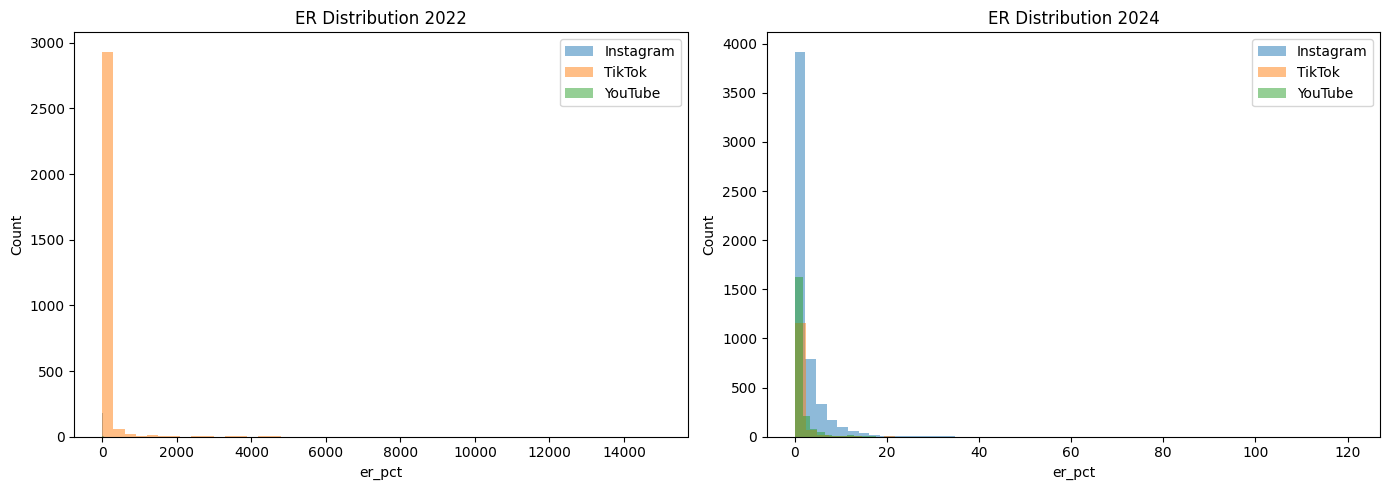

In [49]:
!pip install matplotlib
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [('2022', df22), ('2024', df24)]):
    clean = df[df['er_pct'].notna() & (df['er_pct'] > 0)]
    for platform in ['Instagram', 'TikTok', 'YouTube']:
        sub = clean[clean['platform'] == platform]['er_pct']
        ax.hist(sub, bins=50, alpha=0.5, label=platform)
    ax.set_title(f'ER Distribution {name}')
    ax.set_xlabel('er_pct')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_er_distribution.png', dpi=150)
plt.show()

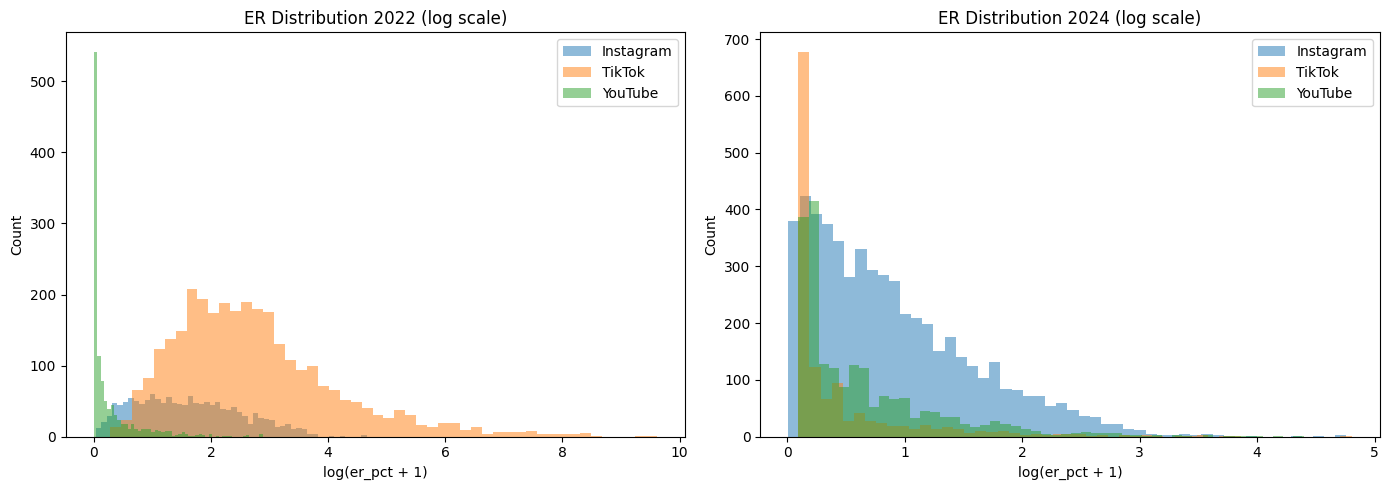

In [50]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [('2022', df22), ('2024', df24)]):
    clean = df[df['er_pct'].notna() & (df['er_pct'] > 0)]
    for platform in ['Instagram', 'TikTok', 'YouTube']:
        sub = np.log1p(clean[clean['platform'] == platform]['er_pct'])
        ax.hist(sub, bins=50, alpha=0.5, label=platform)
    ax.set_title(f'ER Distribution {name} (log scale)')
    ax.set_xlabel('log(er_pct + 1)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_er_distribution_log.png', dpi=150)
plt.show()

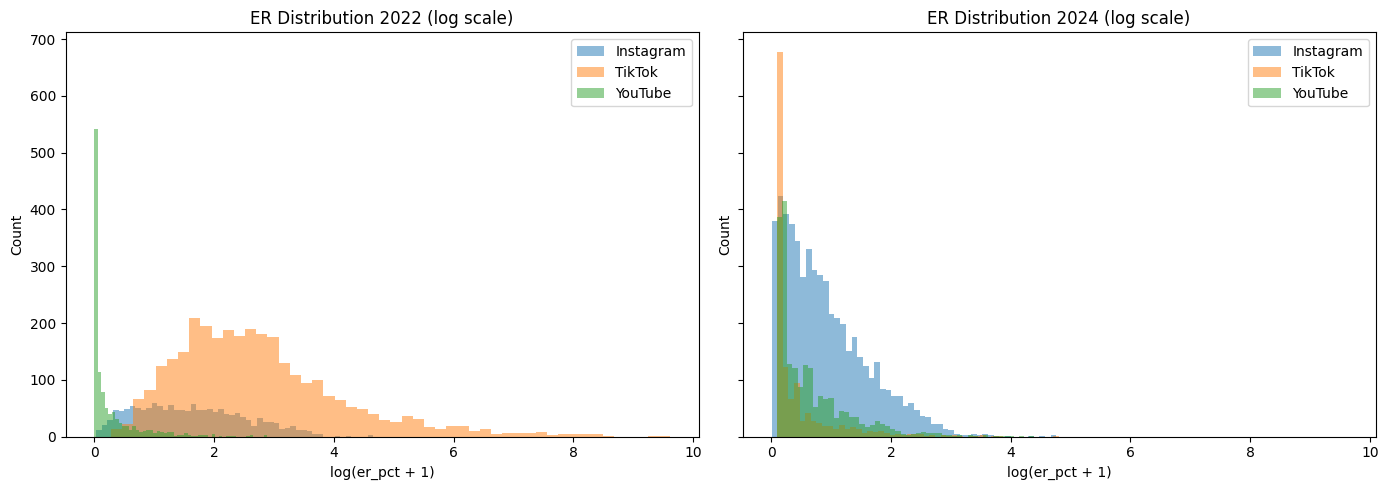

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)

for ax, (name, df) in zip(axes, [('2022', df22), ('2024', df24)]):
    clean = df[df['er_pct'].notna() & (df['er_pct'] > 0)]
    for platform in ['Instagram', 'TikTok', 'YouTube']:
        sub = np.log1p(clean[clean['platform'] == platform]['er_pct'])
        ax.hist(sub, bins=50, alpha=0.5, label=platform)
    ax.set_title(f'ER Distribution {name} (log scale)')
    ax.set_xlabel('log(er_pct + 1)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_er_distribution_log_fixed.png', dpi=150)
plt.show()

In [52]:
df26_raw = pd.read_csv('../cleaned_dataset/updated/merged_2026.csv', encoding='utf-16')
print(df26_raw.shape)
print(df26_raw.columns.tolist())
print(df26_raw[['platform', 'followers', 'er_pct']].describe())

(583, 17)
['year', 'platform', 'month', 'handle', 'name', 'rank', 'followers', 'audience_country', 'category_unified', 'er_pct', 'engagement_avg', 'likes_avg', 'comments_avg', 'views_avg', 'shares_avg', 'potential_reach', 'number_videos_last_year']
           er_pct
count  578.000000
mean     0.135977
std      0.671678
min      0.000000
25%      0.001665
50%      0.011828
75%      0.077434
max     14.065887


In [53]:
yt22 = df22[df22['platform'] == 'YouTube']['er_pct']
yt26 = df26_raw[df26_raw['platform'] == 'YouTube']['er_pct']

print("2022 YouTube er_pct:")
print(yt22.describe())
print("\n2026 YouTube er_pct:")
print(yt26.describe())

2022 YouTube er_pct:
count    1144.000000
mean        0.486423
std         1.408616
min         0.000000
25%         0.007433
50%         0.061457
75%         0.354424
max        16.919271
Name: er_pct, dtype: float64

2026 YouTube er_pct:
count    578.000000
mean       0.135977
std        0.671678
min        0.000000
25%        0.001665
50%        0.011828
75%        0.077434
max       14.065887
Name: er_pct, dtype: float64


In [54]:
df26 = df26_raw[df26_raw['platform'] == 'YouTube'].copy()
df26['followers'] = pd.to_numeric(df26['followers'], errors='coerce')
df26['er_pct'] = pd.to_numeric(df26['er_pct'], errors='coerce')
df26 = df26[['handle', 'followers', 'er_pct', 'category_unified', 'platform']].dropna(subset=['followers', 'er_pct']).reset_index(drop=True)

print(df26.shape)
print(df26.describe())

(578, 5)
          followers      er_pct
count  5.780000e+02  578.000000
mean   2.501820e+07    0.135977
std    3.014653e+07    0.671678
min    2.000000e+00    0.000000
25%    1.350000e+07    0.001665
50%    1.765000e+07    0.011828
75%    2.590000e+07    0.077434
max    4.740000e+08   14.065887


In [55]:
for name, df in [('2022', df22), ('2024', df24)]:
    print(f'\n--- {name} ---')
    print(df.groupby('platform')['category_unified'].nunique())


--- 2022 ---
platform
Instagram    7
TikTok       0
YouTube      7
Name: category_unified, dtype: int64

--- 2024 ---
platform
Instagram    8
TikTok       8
YouTube      8
Name: category_unified, dtype: int64


In [56]:
for name, df in [('2022', df22), ('2024', df24)]:
    print(f'\n--- {name} ---')
    for platform in ['Instagram', 'TikTok', 'YouTube']:
        cats = df[df['platform'] == platform]['category_unified'].dropna().unique()
        print(f"{platform}: {sorted(cats)}")


--- 2022 ---
Instagram: ['Beauty/Fashion', 'Entertainment', 'Info/Business', 'Lifestyle', 'Music', 'Sports', 'Tech/Gaming']
TikTok: []
YouTube: ['Beauty/Fashion', 'Entertainment', 'Info/Business', 'Lifestyle', 'Music', 'Sports', 'Tech/Gaming']

--- 2024 ---
Instagram: ['Beauty/Fashion', 'Entertainment', 'Info/Business', 'Lifestyle', 'Music', 'Others', 'Sports', 'Tech/Gaming']
TikTok: ['Beauty/Fashion', 'Entertainment', 'Info/Business', 'Lifestyle', 'Music', 'Others', 'Sports', 'Tech/Gaming']
YouTube: ['Beauty/Fashion', 'Entertainment', 'Info/Business', 'Lifestyle', 'Music', 'Others', 'Sports', 'Tech/Gaming']


In [57]:
for name, df in [('2022', df22), ('2024', df24)]:
    print(f'\n--- {name} ---')
    for platform in ['Instagram', 'TikTok', 'YouTube']:
        cats = df[df['platform'] == platform]['category_unified'].dropna().unique()
        print(f"{platform}: {sorted(cats)}")


--- 2022 ---
Instagram: ['Beauty/Fashion', 'Entertainment', 'Info/Business', 'Lifestyle', 'Music', 'Sports', 'Tech/Gaming']
TikTok: []
YouTube: ['Beauty/Fashion', 'Entertainment', 'Info/Business', 'Lifestyle', 'Music', 'Sports', 'Tech/Gaming']

--- 2024 ---
Instagram: ['Beauty/Fashion', 'Entertainment', 'Info/Business', 'Lifestyle', 'Music', 'Others', 'Sports', 'Tech/Gaming']
TikTok: ['Beauty/Fashion', 'Entertainment', 'Info/Business', 'Lifestyle', 'Music', 'Others', 'Sports', 'Tech/Gaming']
YouTube: ['Beauty/Fashion', 'Entertainment', 'Info/Business', 'Lifestyle', 'Music', 'Others', 'Sports', 'Tech/Gaming']


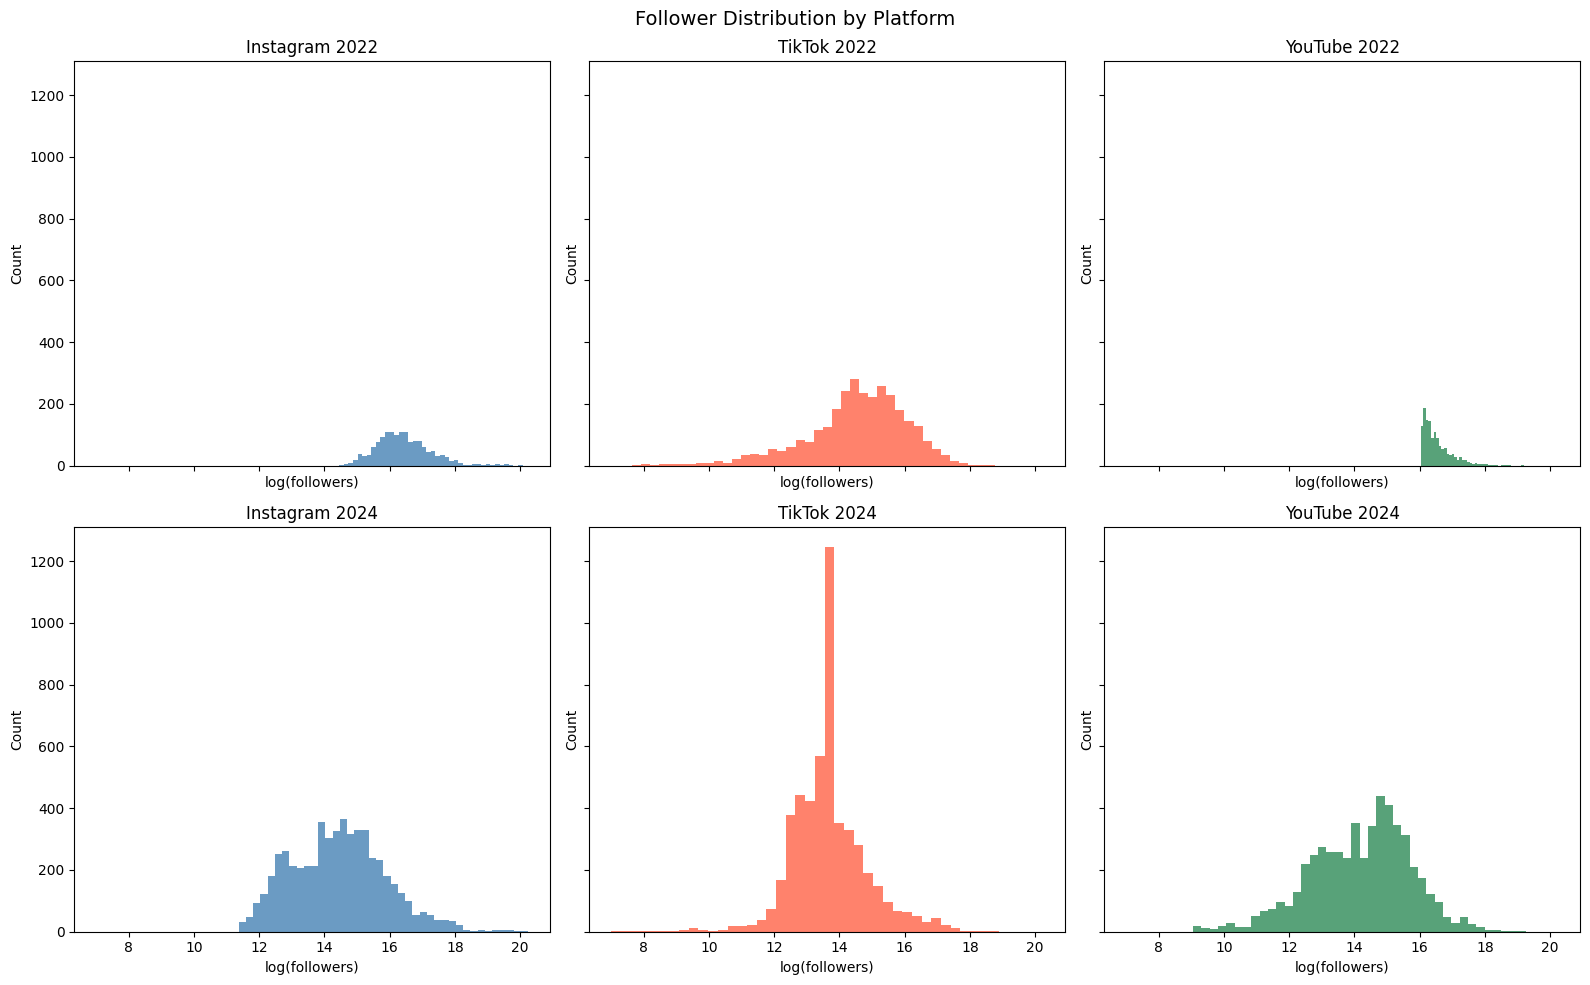

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)

for row, (name, df) in enumerate([('2022', df22), ('2024', df24)]):
    for col, platform in enumerate(['Instagram', 'TikTok', 'YouTube']):
        ax = axes[row, col]
        sub = df[df['platform'] == platform]['followers'].dropna()
        ax.hist(np.log1p(sub), bins=40, color=['steelblue', 'tomato', 'seagreen'][col], alpha=0.8)
        ax.set_title(f'{platform} {name}')
        ax.set_xlabel('log(followers)')
        ax.set_ylabel('Count')

plt.suptitle('Follower Distribution by Platform', fontsize=14)
plt.tight_layout()
plt.savefig('eda_followers.png', dpi=150)
plt.show()

In [60]:
for name, df in [('2022', df22), ('2024', df24)]:
    tt = df[df['platform'] == 'TikTok']
    print(f'\n--- TikTok {name} ---')
    print(tt['followers'].describe())
    print(f"\nRows with followers < 1000: {(tt['followers'] < 1000).sum()}")
    print(tt[tt['followers'] < 1000][['handle', 'followers']].head(10))


--- TikTok 2022 ---
count    3.060000e+03
mean     4.985740e+06
std      8.037595e+06
min      2.100000e+03
25%      9.660750e+05
50%      2.500000e+06
75%      5.800000e+06
max      1.432000e+08
Name: followers, dtype: float64

Rows with followers < 1000: 0
Empty DataFrame
Columns: [handle, followers]
Index: []

--- TikTok 2024 ---
count    5.131000e+03
mean     1.993826e+06
std      5.194443e+06
min      1.100000e+03
25%      4.458000e+05
50%      8.538000e+05
75%      1.400000e+06
max      1.619000e+08
Name: followers, dtype: float64

Rows with followers < 1000: 0
Empty DataFrame
Columns: [handle, followers]
Index: []


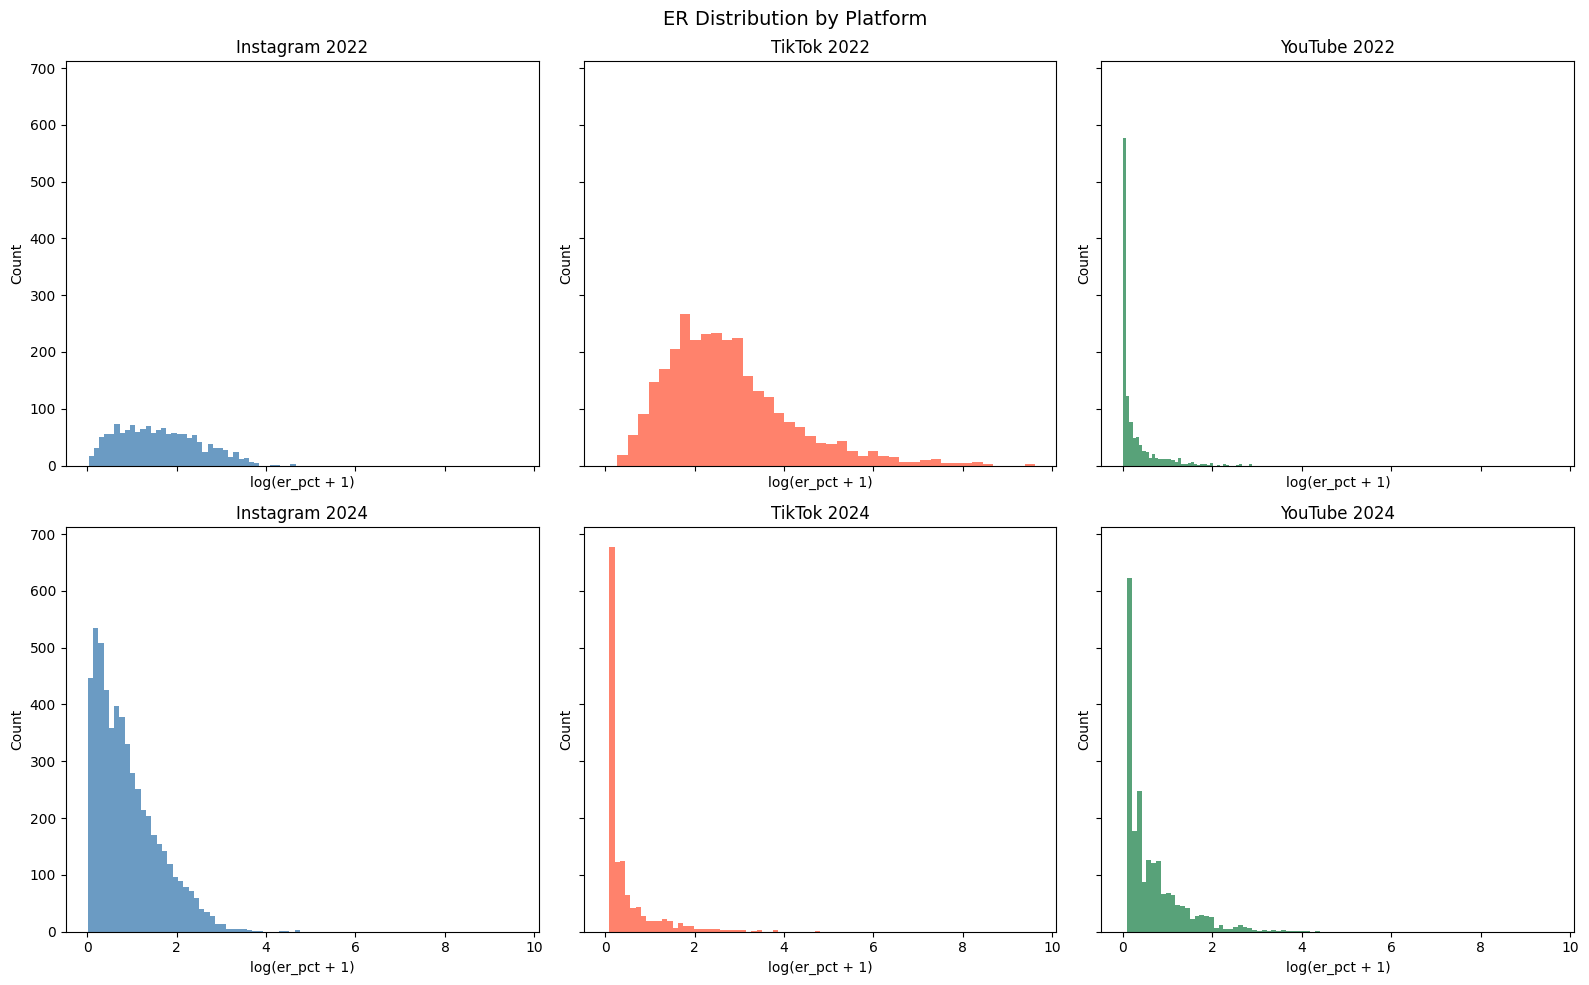

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)

for row, (name, df) in enumerate([('2022', df22), ('2024', df24)]):
    for col, platform in enumerate(['Instagram', 'TikTok', 'YouTube']):
        ax = axes[row, col]
        sub = df[(df['platform'] == platform) & (df['er_pct'] > 0)]['er_pct'].dropna()
        ax.hist(np.log1p(sub), bins=40, color=['steelblue', 'tomato', 'seagreen'][col], alpha=0.8)
        ax.set_title(f'{platform} {name}')
        ax.set_xlabel('log(er_pct + 1)')
        ax.set_ylabel('Count')

plt.suptitle('ER Distribution by Platform', fontsize=14)
plt.tight_layout()
plt.savefig('eda_er.png', dpi=150)
plt.show()

In [64]:
for name, df in [('2022', df22), ('2024', df24)]:
    print(f'\n--- {name} ---')
    for platform in ['Instagram', 'TikTok', 'YouTube']:
        n = df[(df['platform'] == platform) & (df['er_pct'] > 0)]['er_pct'].notna().sum()
        print(f"{platform}: {n}")


--- 2022 ---
Instagram: 1448
TikTok: 3060
YouTube: 1121

--- 2024 ---
Instagram: 5467
TikTok: 1277
YouTube: 2050


In [65]:
for name, df in [('2022', df22), ('2024', df24)]:
    print(f'\n--- {name} ---')
    for platform in ['Instagram', 'TikTok', 'YouTube']:
        n = df[(df['platform'] == platform) & (df['er_pct'] > 0)]['er_pct'].notna().sum()
        print(f"{platform}: {n}")


--- 2022 ---
Instagram: 1448
TikTok: 3060
YouTube: 1121

--- 2024 ---
Instagram: 5467
TikTok: 1277
YouTube: 2050


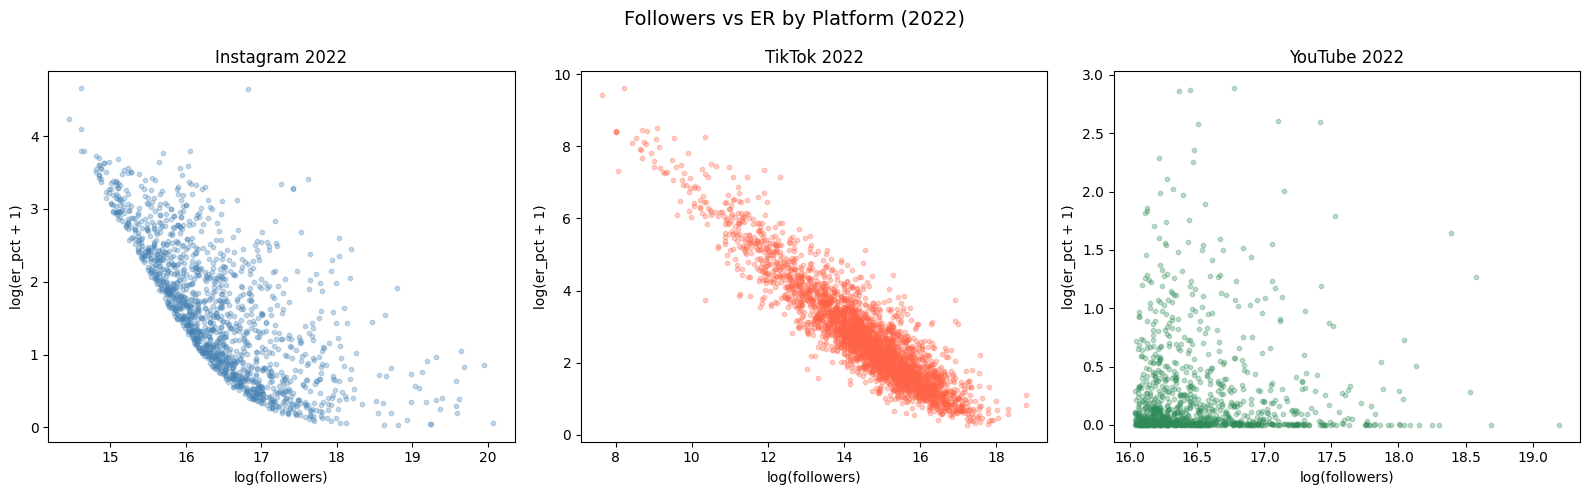

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for col, platform in enumerate(['Instagram', 'TikTok', 'YouTube']):
    ax = axes[col]
    sub = df22[(df22['platform'] == platform) & (df22['er_pct'] > 0)].dropna(subset=['followers', 'er_pct'])
    ax.scatter(np.log1p(sub['followers']), np.log1p(sub['er_pct']), alpha=0.3, s=10, color=['steelblue', 'tomato', 'seagreen'][col])
    ax.set_title(f'{platform} 2022')
    ax.set_xlabel('log(followers)')
    ax.set_ylabel('log(er_pct + 1)')

plt.suptitle('Followers vs ER by Platform (2022)', fontsize=14)
plt.tight_layout()
plt.savefig('eda_scatter_2022.png', dpi=150)
plt.show()

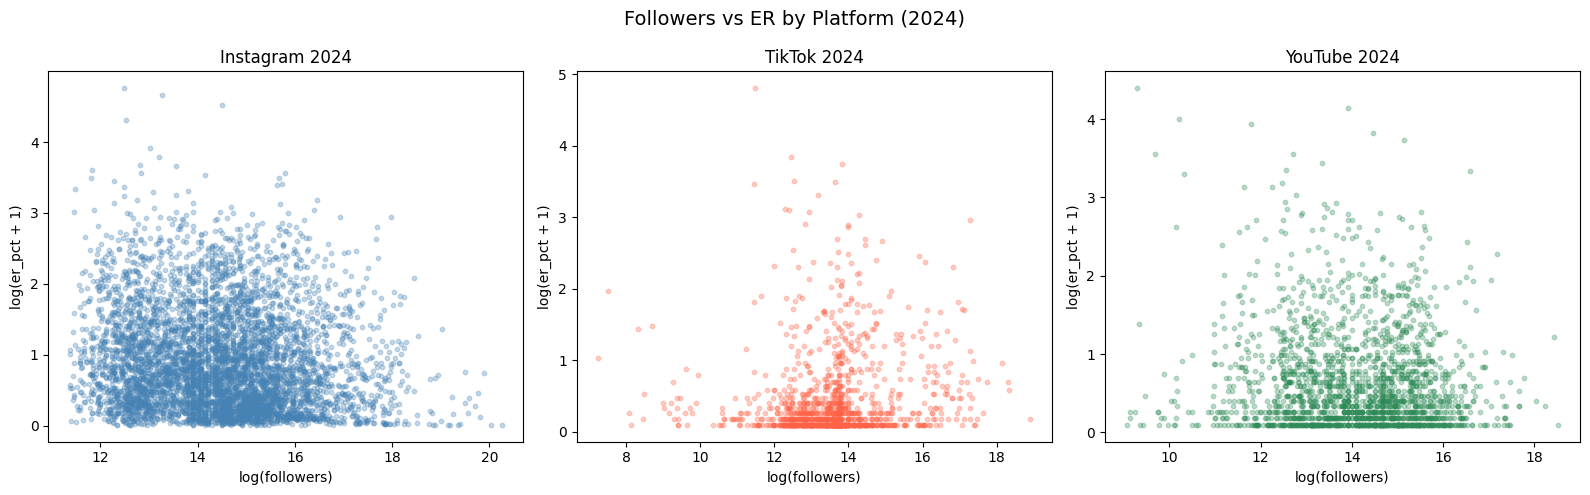

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for col, platform in enumerate(['Instagram', 'TikTok', 'YouTube']):
    ax = axes[col]
    sub = df24[(df24['platform'] == platform) & (df24['er_pct'] > 0)].dropna(subset=['followers', 'er_pct'])
    ax.scatter(np.log1p(sub['followers']), np.log1p(sub['er_pct']), alpha=0.3, s=10, color=['steelblue', 'tomato', 'seagreen'][col])
    ax.set_title(f'{platform} 2024')
    ax.set_xlabel('log(followers)')
    ax.set_ylabel('log(er_pct + 1)')

plt.suptitle('Followers vs ER by Platform (2024)', fontsize=14)
plt.tight_layout()
plt.savefig('eda_scatter_2024.png', dpi=150)
plt.show()

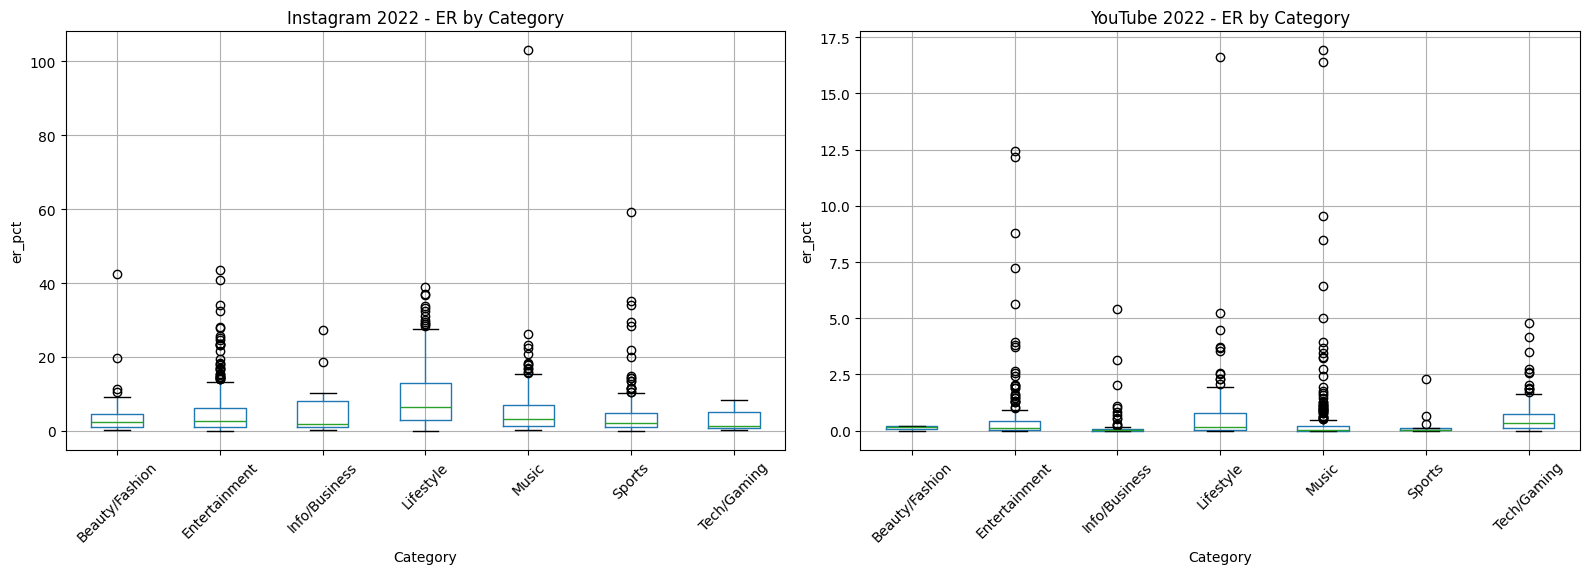

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, platform in zip(axes, ['Instagram', 'YouTube']):
    sub = df22[(df22['platform'] == platform) & (df22['er_pct'] > 0)].dropna(subset=['category_unified', 'er_pct'])
    sub.boxplot(column='er_pct', by='category_unified', ax=ax)
    ax.set_title(f'{platform} 2022 - ER by Category')
    ax.set_xlabel('Category')
    ax.set_ylabel('er_pct')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_er_by_category_2022.png', dpi=150)
plt.show()

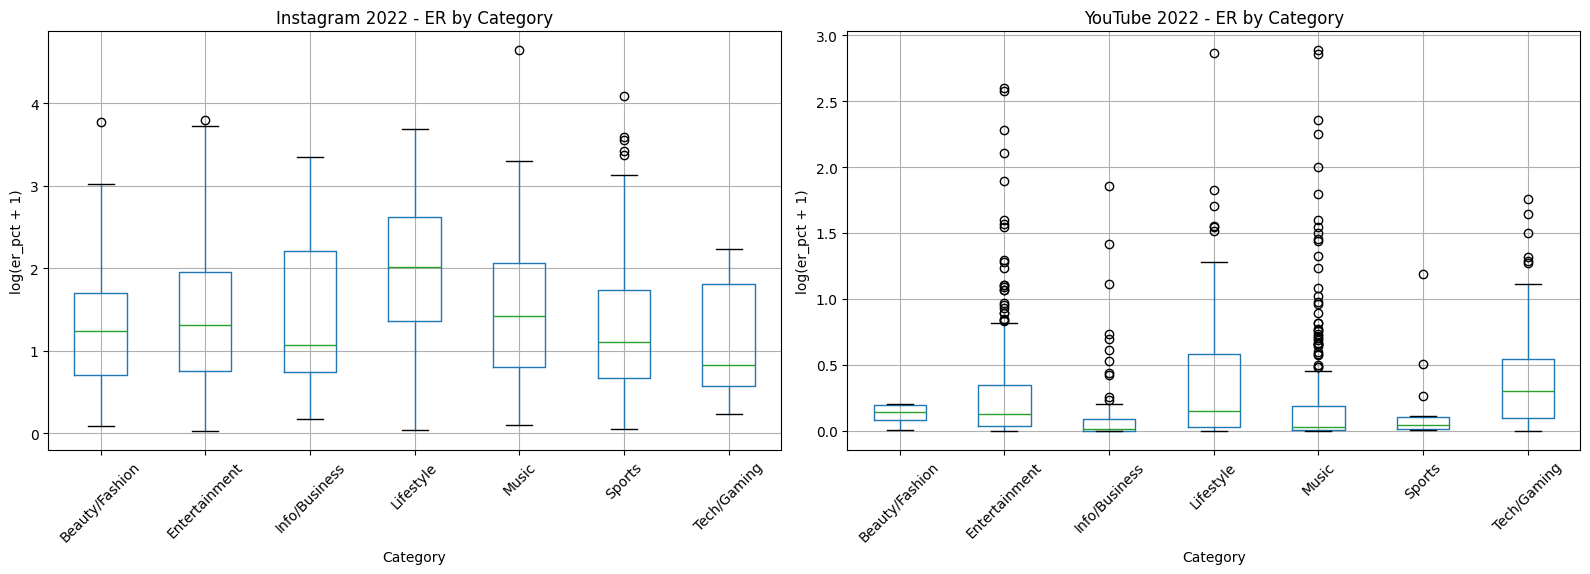

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, platform in zip(axes, ['Instagram', 'YouTube']):
    sub = df22[(df22['platform'] == platform) & (df22['er_pct'] > 0)].dropna(subset=['category_unified', 'er_pct'])
    sub = sub.copy()
    sub['log_er'] = np.log1p(sub['er_pct'])
    sub.boxplot(column='log_er', by='category_unified', ax=ax)
    ax.set_title(f'{platform} 2022 - ER by Category')
    ax.set_xlabel('Category')
    ax.set_ylabel('log(er_pct + 1)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_er_by_category_2022_log.png', dpi=150)
plt.show()

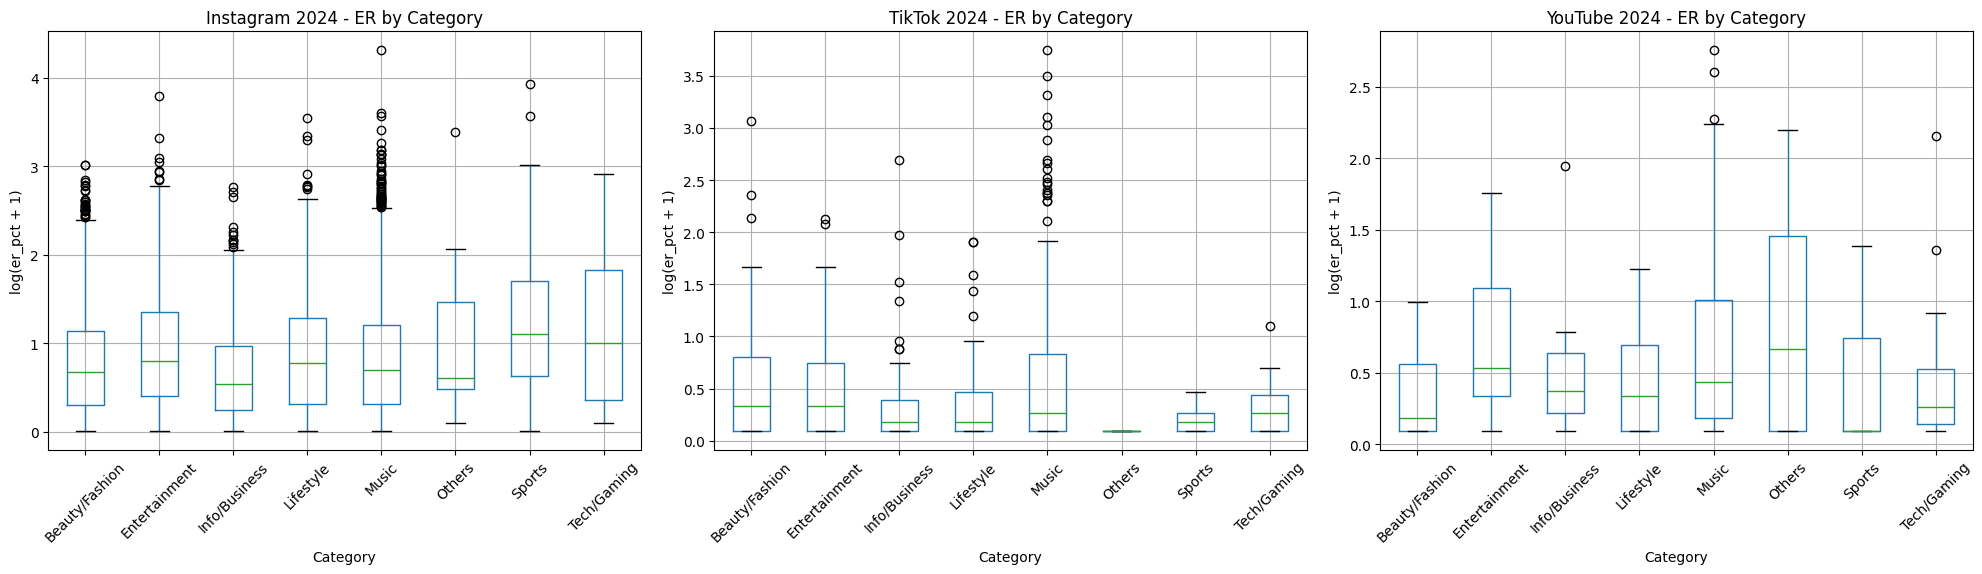

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, platform in zip(axes, ['Instagram', 'TikTok', 'YouTube']):
    sub = df24[(df24['platform'] == platform) & (df24['er_pct'] > 0)].dropna(subset=['category_unified', 'er_pct']).copy()
    sub['log_er'] = np.log1p(sub['er_pct'])
    sub.boxplot(column='log_er', by='category_unified', ax=ax)
    ax.set_title(f'{platform} 2024 - ER by Category')
    ax.set_xlabel('Category')
    ax.set_ylabel('log(er_pct + 1)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_er_by_category_2024_log.png', dpi=150)
plt.show()

In [71]:
tt24_others = df24[(df24['platform'] == 'TikTok') & (df24['category_unified'] == 'Others')]
print(f"Count: {len(tt24_others)}")
print(tt24_others['er_pct'].describe())

Count: 1
count    1.0
mean     0.1
std      NaN
min      0.1
25%      0.1
50%      0.1
75%      0.1
max      0.1
Name: er_pct, dtype: float64


In [72]:
ig22 = df22[df22['platform'] == 'Instagram'].dropna(subset=['audience_country'])
yt22 = df22[df22['platform'] == 'YouTube'].dropna(subset=['audience_country'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (platform, sub) in zip(axes, [('Instagram', ig22), ('YouTube', yt22)]):
    top10 = sub['audience_country'].value_counts().head(10)
    top10.plot(kind='bar', ax=ax, color='steelblue' if platform == 'Instagram' else 'seagreen')
    ax.set_title(f'{platform} 2022 - Top 10 Countries')
    ax.set_xlabel('Country')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_country_2022.png', dpi=150)
plt.show()

KeyError: ['audience_country']

In [73]:
def load_instagram_2022():
    dfs = []
    for s in ['june', 'march', 'september', 'november', 'december']:
        df = pd.read_csv(f'../cleaned_dataset/2022/instagram_{s}.csv')
        df = df.rename(columns={'handle_instagram': 'handle', 'unified_cat_1': 'category_unified'})
        df['followers'] = pd.to_numeric(df['followers'], errors='coerce')
        df['engagement_avg'] = pd.to_numeric(df['engagement_avg'], errors='coerce')
        df['er_pct'] = df['engagement_avg'] / df['followers'] * 100
        df['platform'] = 'Instagram'
        dfs.append(df[['handle', 'followers', 'er_pct', 'category_unified', 'audience_country', 'platform']])
    return pd.concat(dfs).drop_duplicates(subset='handle').reset_index(drop=True)

def load_tiktok_2022():
    dfs = []
    for s in ['june', 'march', 'september', 'november', 'december']:
        df = pd.read_csv(f'../cleaned_dataset/2022/tiktok_{s}.csv')
        df = df.rename(columns={'handle_tiktok': 'handle'})
        df['followers'] = pd.to_numeric(df['followers'], errors='coerce')
        df['likes_avg'] = pd.to_numeric(df['likes_avg'], errors='coerce')
        df['comments_avg'] = pd.to_numeric(df['comments_avg'], errors='coerce')
        df['er_pct'] = (df['likes_avg'] + df['comments_avg']) / df['followers'] * 100
        df['category_unified'] = np.nan
        df['audience_country'] = np.nan
        df['platform'] = 'TikTok'
        dfs.append(df[['handle', 'followers', 'er_pct', 'category_unified', 'audience_country', 'platform']])
    return pd.concat(dfs).drop_duplicates(subset='handle').reset_index(drop=True)

def load_youtube_2022():
    dfs = []
    for s in ['june', 'march', 'september', 'november', 'december']:
        df = pd.read_csv(f'../cleaned_dataset/2022/youtube_{s}.csv')
        df = df.rename(columns={'handle_youtube': 'handle', 'unified_cat_1': 'category_unified'})
        df['followers'] = pd.to_numeric(df['followers'], errors='coerce')
        df['likes_avg'] = pd.to_numeric(df['likes_avg'], errors='coerce')
        df['comments_avg'] = pd.to_numeric(df['comments_avg'], errors='coerce')
        df['er_pct'] = (df['likes_avg'] + df['comments_avg']) / df['followers'] * 100
        df['platform'] = 'YouTube'
        dfs.append(df[['handle', 'followers', 'er_pct', 'category_unified', 'audience_country', 'platform']])
    return pd.concat(dfs).drop_duplicates(subset='handle').reset_index(drop=True)

ig = load_instagram_2022()
tt = load_tiktok_2022()
yt = load_youtube_2022()

df22 = pd.concat([ig, tt, yt]).reset_index(drop=True)
print(df22.columns.tolist())
print(df22.groupby('platform').size())

['handle', 'followers', 'er_pct', 'category_unified', 'audience_country', 'platform']
platform
Instagram    1463
TikTok       3060
YouTube      1358
dtype: int64


In [74]:
dfs_24 = []
for p, label in [('instagram', 'Instagram'), ('tiktok', 'TikTok'), ('youtube', 'YouTube')]:
    df = pd.read_csv(f'../cleaned_dataset/2024/separate countries/2024_{p}_allcountries_unified.csv')
    df = df.rename(columns={'er': 'er_pct', 'unified_category': 'category_unified', 'country': 'audience_country'})
    df['followers'] = pd.to_numeric(df['followers'], errors='coerce')
    df['er_pct'] = pd.to_numeric(df['er_pct'], errors='coerce')
    df['platform'] = label
    dfs_24.append(df[['handle', 'followers', 'er_pct', 'category_unified', 'audience_country', 'platform']])

df24 = pd.concat(dfs_24).drop_duplicates(subset='handle').reset_index(drop=True)
print(df24.columns.tolist())
print(df24.groupby('platform').size())

['handle', 'followers', 'er_pct', 'category_unified', 'audience_country', 'platform']
platform
Instagram    5530
TikTok       5131
YouTube      5337
dtype: int64


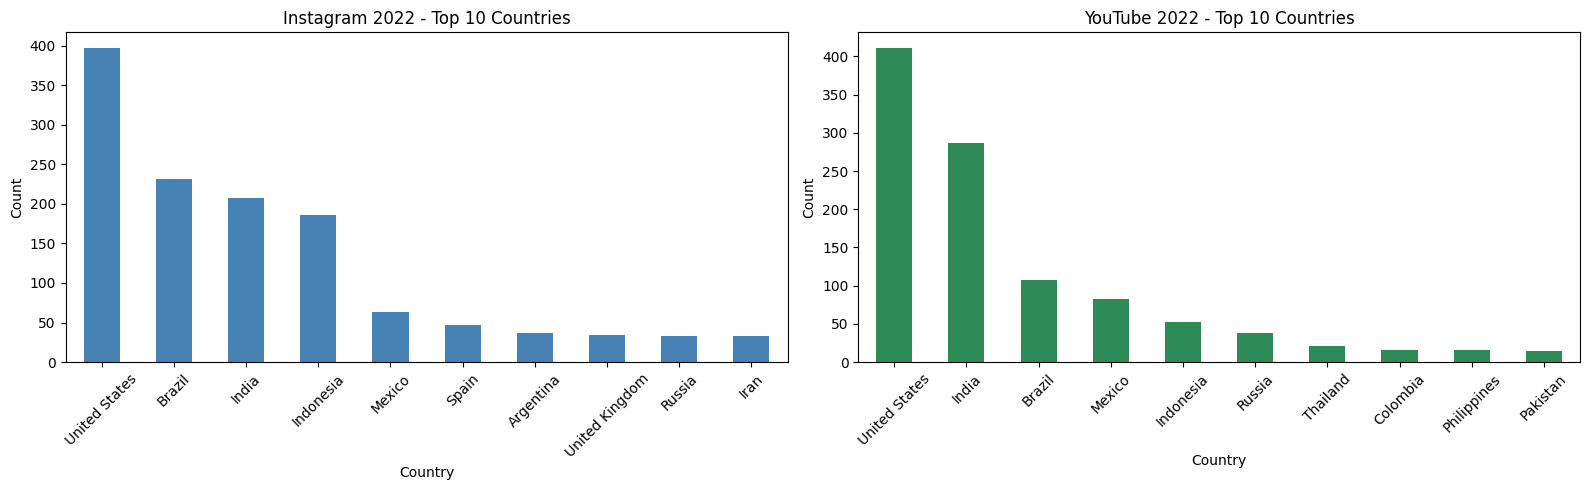

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, platform, color in zip(axes, ['Instagram', 'YouTube'], ['steelblue', 'seagreen']):
    sub = df22[(df22['platform'] == platform)].dropna(subset=['audience_country'])
    top10 = sub['audience_country'].value_counts().head(10)
    top10.plot(kind='bar', ax=ax, color=color)
    ax.set_title(f'{platform} 2022 - Top 10 Countries')
    ax.set_xlabel('Country')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_country_2022.png', dpi=150)
plt.show()

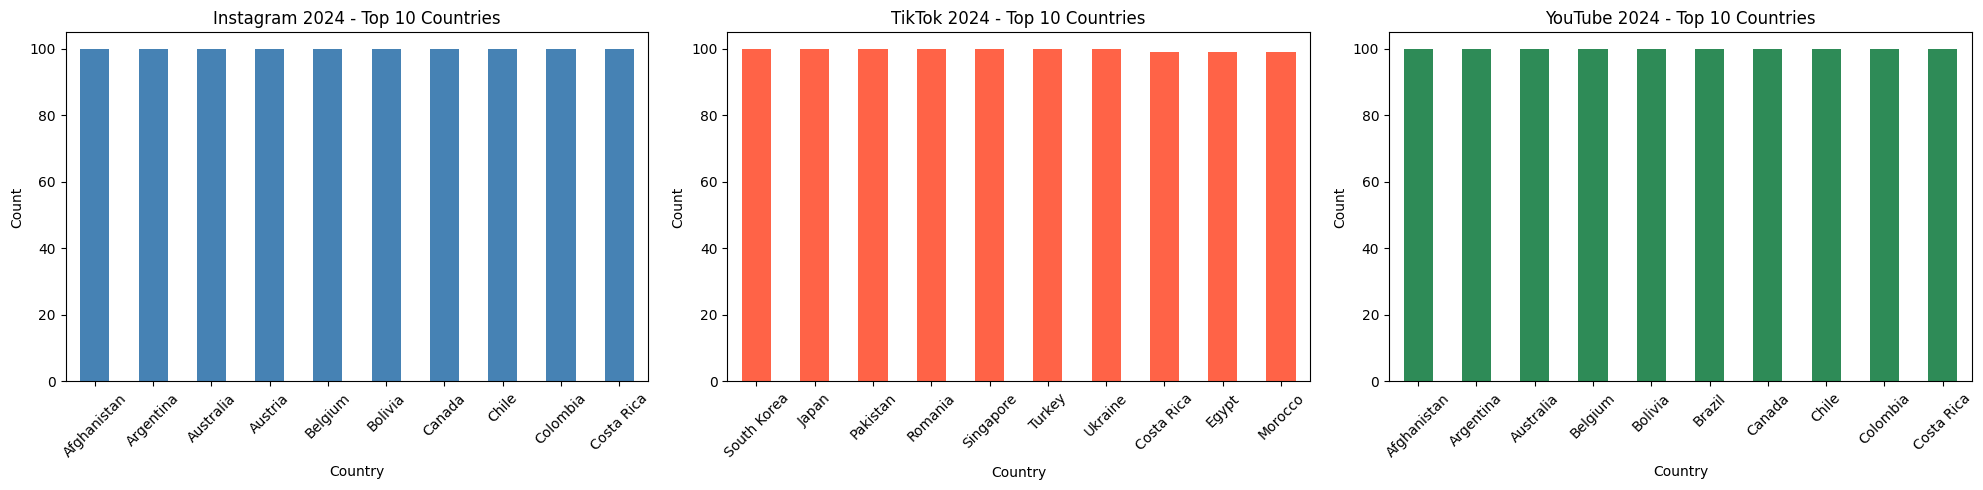

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, platform, color in zip(axes, ['Instagram', 'TikTok', 'YouTube'], ['steelblue', 'tomato', 'seagreen']):
    sub = df24[df24['platform'] == platform].dropna(subset=['audience_country'])
    top10 = sub['audience_country'].value_counts().head(10)
    top10.plot(kind='bar', ax=ax, color=color)
    ax.set_title(f'{platform} 2024 - Top 10 Countries')
    ax.set_xlabel('Country')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_country_2024.png', dpi=150)
plt.show()

In [77]:
dfs_24_top = []
for p, label in [('instagram', 'Instagram'), ('tiktok', 'TikTok'), ('youtube', 'YouTube')]:
    df = pd.read_csv(f'../cleaned_dataset/2024/all countries top/2024_{p}_allcountries_unified.csv')
    df = df.rename(columns={'er': 'er_pct', 'unified_category': 'category_unified', 'country': 'audience_country'})
    df['followers'] = pd.to_numeric(df['followers'], errors='coerce')
    df['er_pct'] = pd.to_numeric(df['er_pct'], errors='coerce')
    df['platform'] = label
    dfs_24_top.append(df[['handle', 'followers', 'er_pct', 'category_unified', 'audience_country', 'platform']])

df24_top = pd.concat(dfs_24_top).reset_index(drop=True)
print(df24_top.groupby('platform').size())

platform
Instagram    100
TikTok       100
YouTube      100
dtype: int64


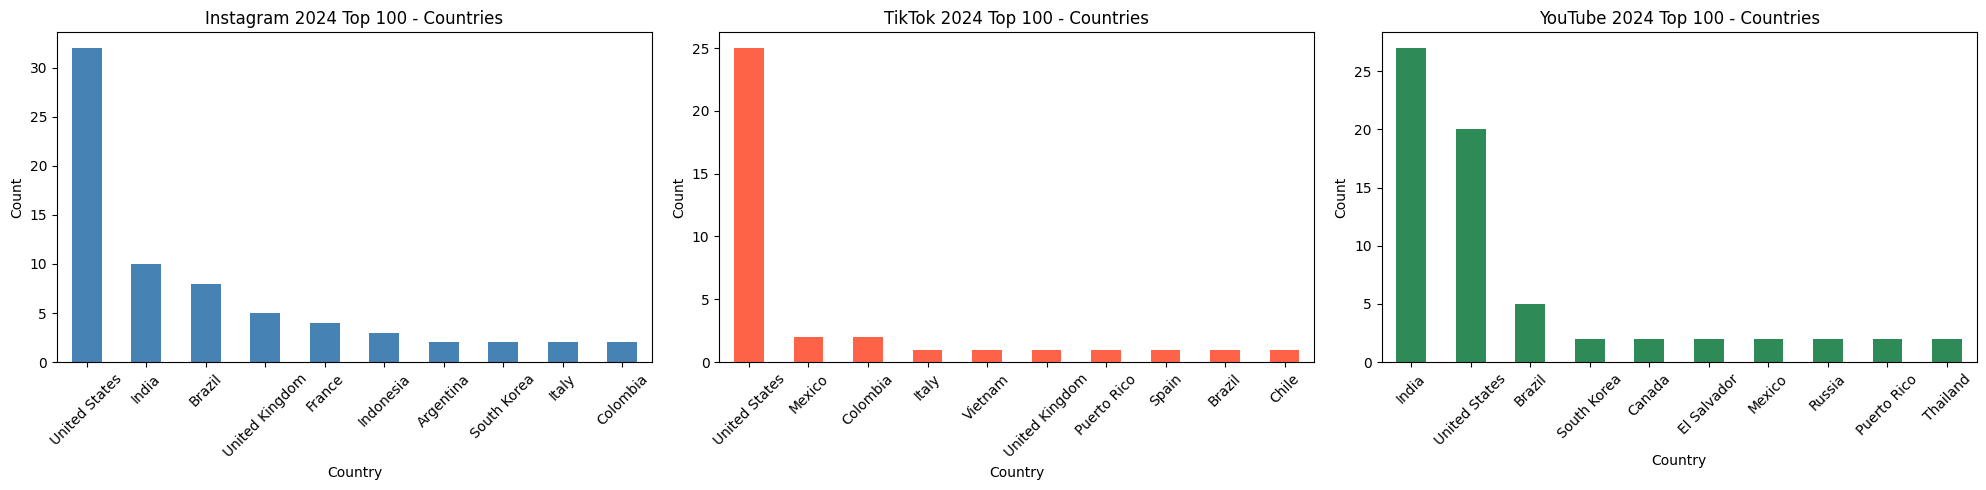

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, platform, color in zip(axes, ['Instagram', 'TikTok', 'YouTube'], ['steelblue', 'tomato', 'seagreen']):
    sub = df24_top[df24_top['platform'] == platform].dropna(subset=['audience_country'])
    top10 = sub['audience_country'].value_counts().head(10)
    top10.plot(kind='bar', ax=ax, color=color)
    ax.set_title(f'{platform} 2024 Top 100 - Countries')
    ax.set_xlabel('Country')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_country_2024_top100.png', dpi=150)
plt.show()

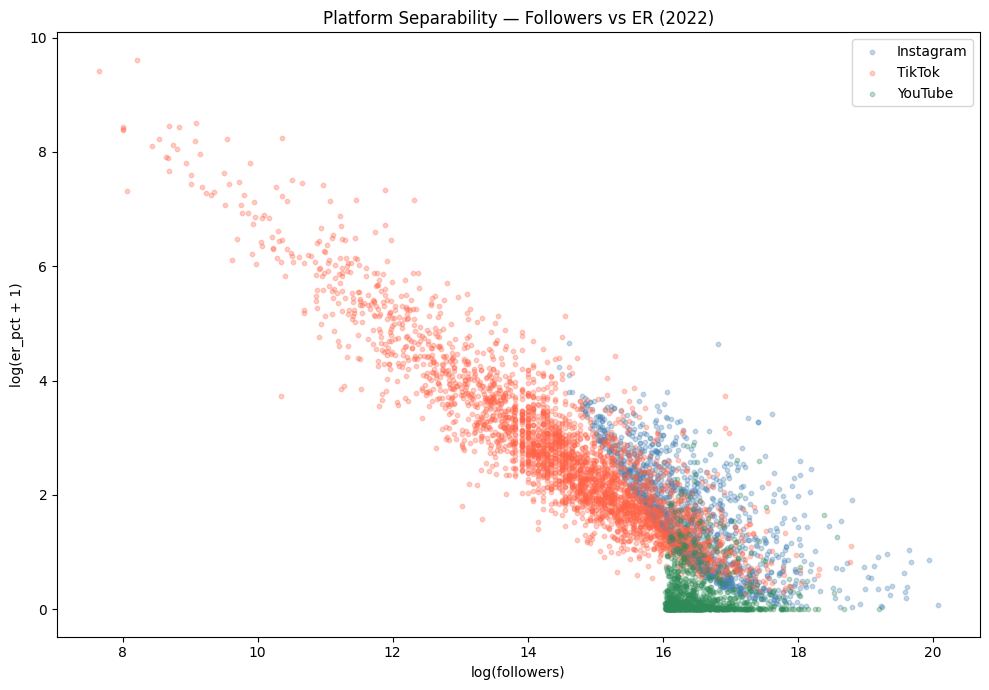

In [79]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'Instagram': 'steelblue', 'TikTok': 'tomato', 'YouTube': 'seagreen'}

for platform in ['Instagram', 'TikTok', 'YouTube']:
    sub = df22[(df22['platform'] == platform) & (df22['er_pct'] > 0)].dropna(subset=['followers', 'er_pct'])
    ax.scatter(np.log1p(sub['followers']), np.log1p(sub['er_pct']),
               alpha=0.3, s=10, color=colors[platform], label=platform)

ax.set_xlabel('log(followers)')
ax.set_ylabel('log(er_pct + 1)')
ax.set_title('Platform Separability — Followers vs ER (2022)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_rq3_separability_2022.png', dpi=150)
plt.show()

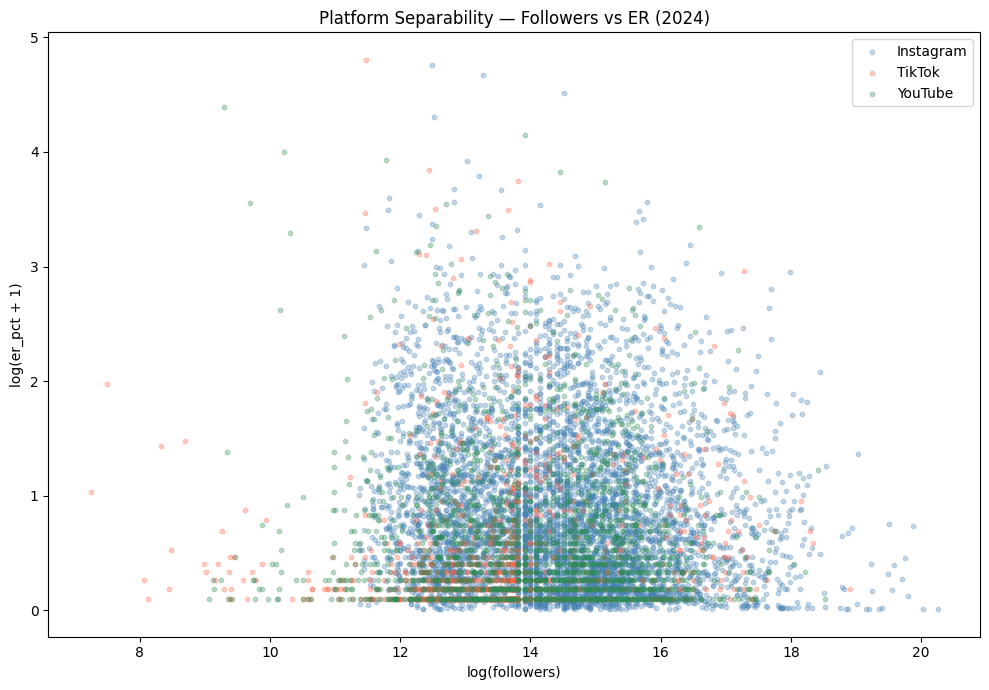

In [80]:
fig, ax = plt.subplots(figsize=(10, 7))

for platform in ['Instagram', 'TikTok', 'YouTube']:
    sub = df24[(df24['platform'] == platform) & (df24['er_pct'] > 0)].dropna(subset=['followers', 'er_pct'])
    ax.scatter(np.log1p(sub['followers']), np.log1p(sub['er_pct']),
               alpha=0.3, s=10, color=colors[platform], label=platform)

ax.set_xlabel('log(followers)')
ax.set_ylabel('log(er_pct + 1)')
ax.set_title('Platform Separability — Followers vs ER (2024)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_rq3_separability_2024.png', dpi=150)
plt.show()

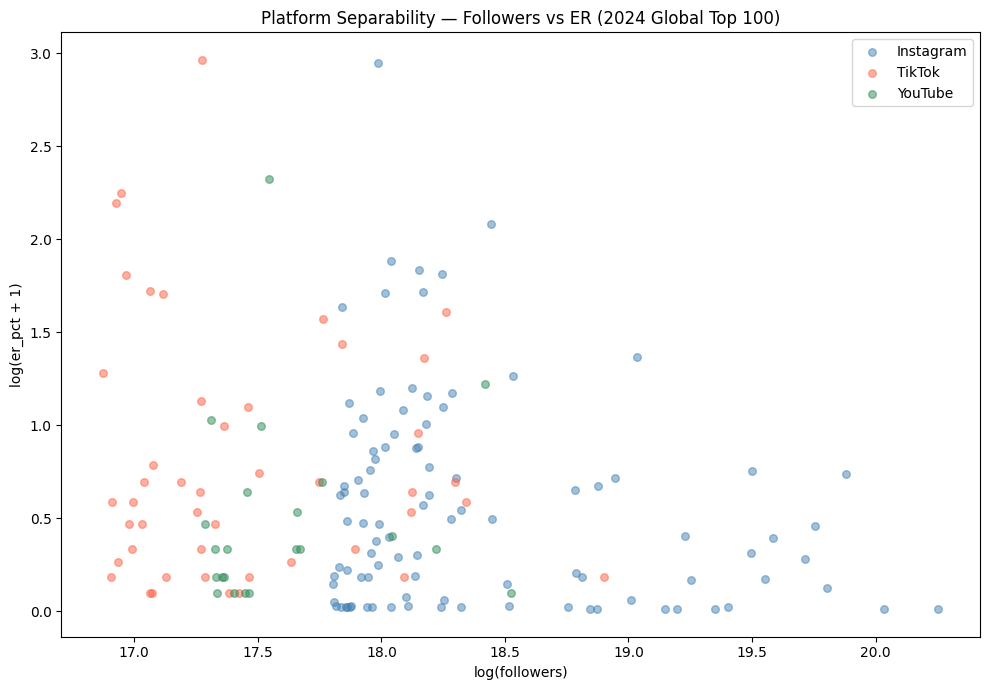

In [81]:
fig, ax = plt.subplots(figsize=(10, 7))

for platform in ['Instagram', 'TikTok', 'YouTube']:
    sub = df24_top[(df24_top['platform'] == platform) & (df24_top['er_pct'] > 0)].dropna(subset=['followers', 'er_pct'])
    ax.scatter(np.log1p(sub['followers']), np.log1p(sub['er_pct']),
               alpha=0.5, s=30, color=colors[platform], label=platform)

ax.set_xlabel('log(followers)')
ax.set_ylabel('log(er_pct + 1)')
ax.set_title('Platform Separability — Followers vs ER (2024 Global Top 100)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_rq3_separability_2024_top100.png', dpi=150)
plt.show()

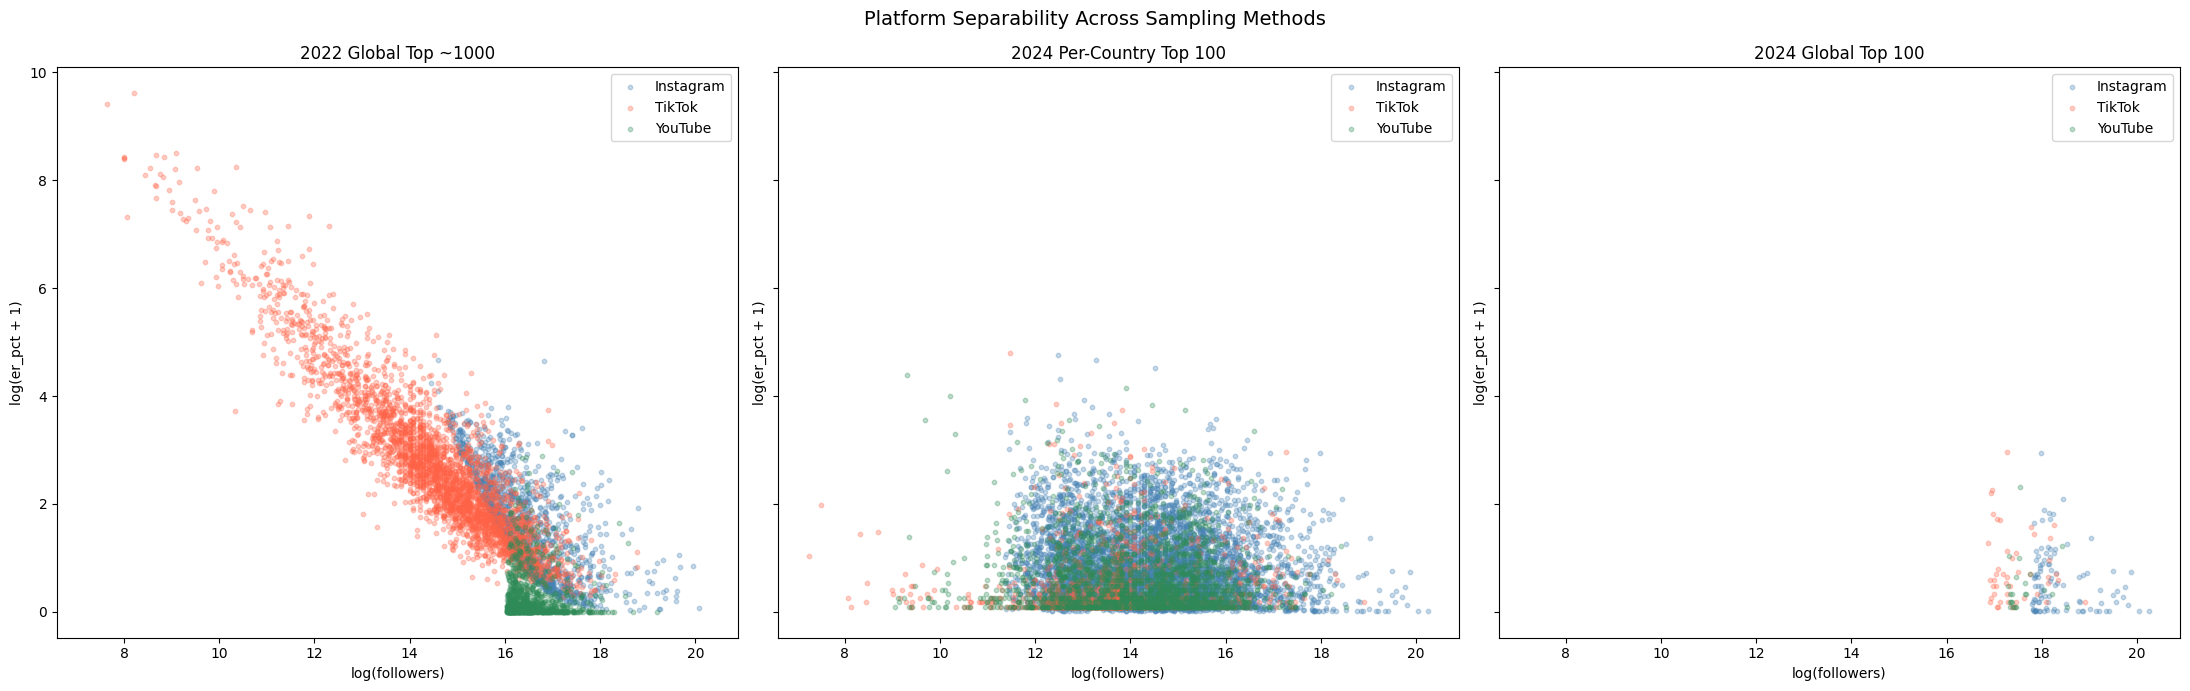

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharex=True, sharey=True)

datasets = [
    ('2022 Global Top ~1000', df22),
    ('2024 Per-Country Top 100', df24),
    ('2024 Global Top 100', df24_top)
]

for ax, (title, df) in zip(axes, datasets):
    for platform in ['Instagram', 'TikTok', 'YouTube']:
        sub = df[(df['platform'] == platform) & (df['er_pct'] > 0)].dropna(subset=['followers', 'er_pct'])
        ax.scatter(np.log1p(sub['followers']), np.log1p(sub['er_pct']),
                   alpha=0.3, s=10, color=colors[platform], label=platform)
    ax.set_xlabel('log(followers)')
    ax.set_ylabel('log(er_pct + 1)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Platform Separability Across Sampling Methods', fontsize=14)
plt.tight_layout()
plt.savefig('eda_rq3_separability_comparison.png', dpi=150)
plt.show()

In [86]:
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn'], capture_output=True)

from sklearn.preprocessing import LabelEncoder
print("sklearn imported successfully")
from sklearn.preprocessing import LabelEncoder

# Keep only rows with valid er_pct and followers
rq3_22 = df22[df22['er_pct'].notna() & df22['followers'].notna() & (df22['er_pct'] > 0)].copy()

# Log transform
rq3_22['log_followers'] = np.log1p(rq3_22['followers'])
rq3_22['log_er'] = np.log1p(rq3_22['er_pct'])

# Encode category (NaN → 'Unknown')
rq3_22['category_unified'] = rq3_22['category_unified'].fillna('Unknown')

print(rq3_22.groupby('platform').size())
print(f"\nCategory counts:\n{rq3_22['category_unified'].value_counts()}")

sklearn imported successfully
platform
Instagram    1448
TikTok       3060
YouTube      1121
dtype: int64

Category counts:
category_unified
Unknown           3554
Entertainment      614
Music              568
Lifestyle          340
Sports             208
Tech/Gaming        117
Info/Business      114
Beauty/Fashion     114
Name: count, dtype: int64


In [87]:
import pandas as pd

# One-hot encode category
cat_dummies = pd.get_dummies(rq3_22['category_unified'], prefix='cat')

# Build feature matrix
X = pd.concat([
    rq3_22[['log_followers', 'log_er']].reset_index(drop=True),
    cat_dummies.reset_index(drop=True)
], axis=1)

# Target
y = rq3_22['platform'].reset_index(drop=True)

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")
print(f"\nFeature columns:\n{X.columns.tolist()}")

X shape: (5629, 10)
y distribution:
platform
TikTok       3060
Instagram    1448
YouTube      1121
Name: count, dtype: int64

Feature columns:
['log_followers', 'log_er', 'cat_Beauty/Fashion', 'cat_Entertainment', 'cat_Info/Business', 'cat_Lifestyle', 'cat_Music', 'cat_Sports', 'cat_Tech/Gaming', 'cat_Unknown']


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain distribution:\n{y_train.value_counts()}")
print(f"\nTest distribution:\n{y_test.value_counts()}")

Train: (4503, 10), Test: (1126, 10)

Train distribution:
platform
TikTok       2448
Instagram    1158
YouTube       897
Name: count, dtype: int64

Test distribution:
platform
TikTok       612
Instagram    290
YouTube      224
Name: count, dtype: int64


In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [90]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

   Instagram       0.91      0.82      0.87       290
      TikTok       0.96      0.96      0.96       612
     YouTube       0.81      0.92      0.86       224

    accuracy                           0.91      1126
   macro avg       0.89      0.90      0.90      1126
weighted avg       0.92      0.91      0.91      1126



In [91]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

   Instagram       0.90      0.92      0.91       290
      TikTok       0.97      0.98      0.97       612
     YouTube       0.94      0.90      0.92       224

    accuracy                           0.95      1126
   macro avg       0.94      0.93      0.94      1126
weighted avg       0.95      0.95      0.95      1126



In [92]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], capture_output=True)

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train_enc)
y_pred_xgb = le.inverse_transform(xgb.predict(X_test))

print("XGBoost:")
print(classification_report(y_test, y_pred_xgb))

XGBoost:
              precision    recall  f1-score   support

   Instagram       0.88      0.92      0.90       290
      TikTok       0.97      0.97      0.97       612
     YouTube       0.93      0.89      0.91       224

    accuracy                           0.94      1126
   macro avg       0.93      0.92      0.93      1126
weighted avg       0.94      0.94      0.94      1126



In [93]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', class_weight='balanced', random_state=42, probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM (RBF):")
print(classification_report(y_test, y_pred_svm))

SVM (RBF):
              precision    recall  f1-score   support

   Instagram       0.92      0.82      0.87       290
      TikTok       0.96      0.95      0.95       612
     YouTube       0.79      0.91      0.85       224

    accuracy                           0.91      1126
   macro avg       0.89      0.90      0.89      1126
weighted avg       0.91      0.91      0.91      1126



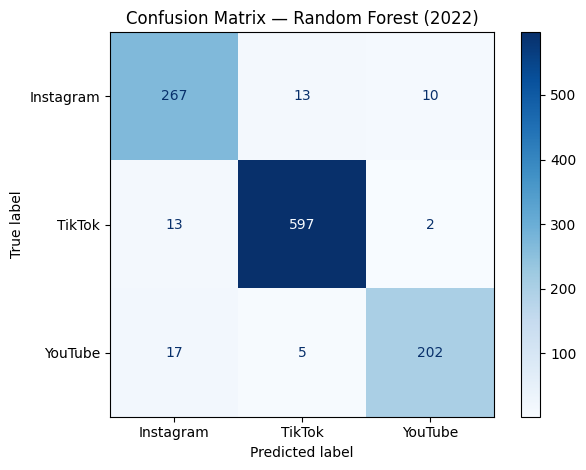

In [94]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf, labels=['Instagram', 'TikTok', 'YouTube'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Instagram', 'TikTok', 'YouTube'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest (2022)')
plt.tight_layout()
plt.savefig('rq3_confusion_matrix_rf.png', dpi=150)
plt.show()

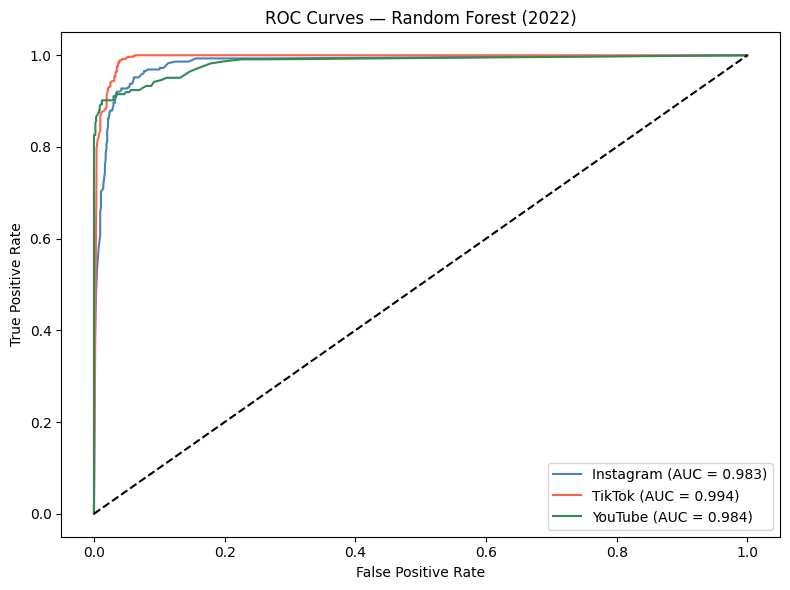

In [95]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = ['Instagram', 'TikTok', 'YouTube']
y_test_bin = label_binarize(y_test, classes=classes)
y_score = rf.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['steelblue', 'tomato', 'seagreen']

for i, (cls, color) in enumerate(zip(classes, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Random Forest (2022)')
ax.legend()
plt.tight_layout()
plt.savefig('rq3_roc_rf.png', dpi=150)
plt.show()

In [96]:
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb,
    'SVM': svm
}

print("10-fold CV Accuracy (mean ± std):")
for name, model in models.items():
    if name == 'XGBoost':
        scores = cross_val_score(model, X, le.transform(y), cv=10, scoring='accuracy')
    else:
        scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

10-fold CV Accuracy (mean ± std):
Logistic Regression: 0.910 ± 0.021
Random Forest: 0.933 ± 0.022
XGBoost: 0.934 ± 0.024
SVM: 0.906 ± 0.026


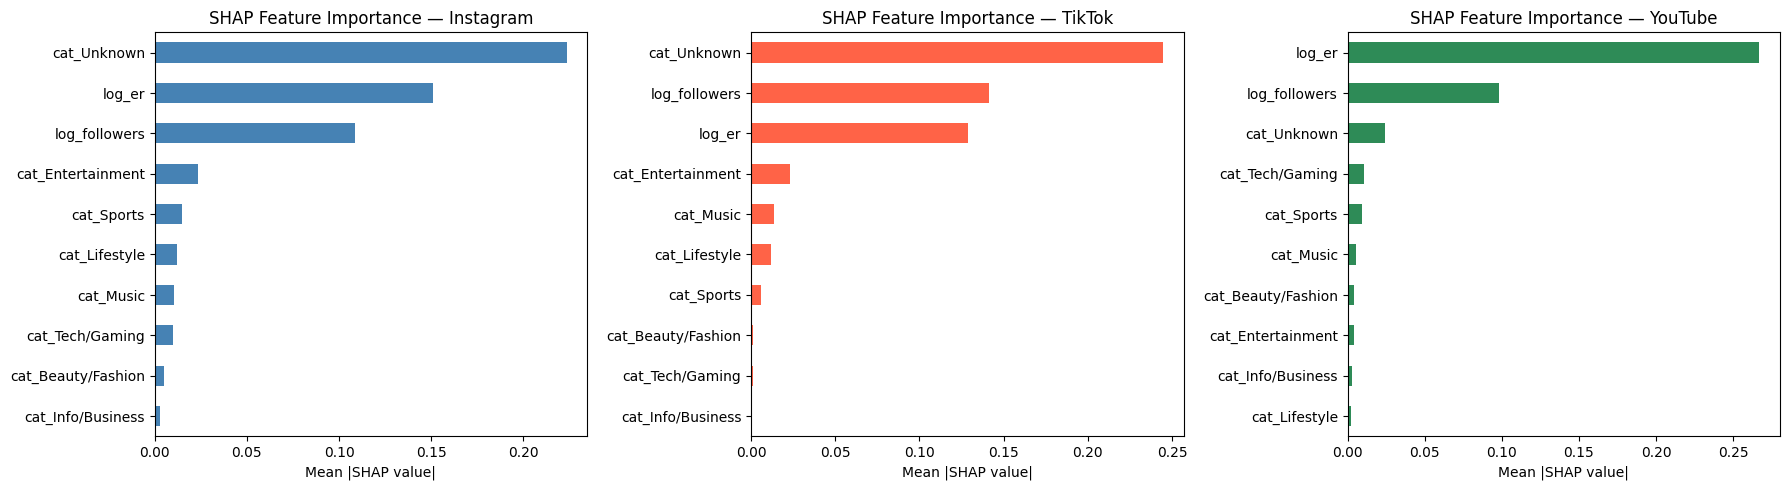

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
classes = ['Instagram', 'TikTok', 'YouTube']

for i, (cls, ax) in enumerate(zip(classes, axes)):
    shap_mean = np.abs(shap_values[:, :, i]).mean(axis=0)
    feat_imp = pd.Series(shap_mean, index=X.columns).sort_values(ascending=True)
    feat_imp.plot(kind='barh', ax=ax, color=colors[cls])
    ax.set_title(f'SHAP Feature Importance — {cls}')
    ax.set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.savefig('rq3_shap_per_class.png', dpi=150)
plt.show()

In [103]:
print(rq3_22.groupby(['platform', 'category_unified']).size().unstack(fill_value=0))

category_unified  Beauty/Fashion  Entertainment  Info/Business  Lifestyle  \
platform                                                                    
Instagram                    104            408             27        248   
TikTok                         0              0              0          0   
YouTube                       10            206             87         92   

category_unified  Music  Sports  Tech/Gaming  Unknown  
platform                                               
Instagram           299     193           14      155  
TikTok                0       0            0     3060  
YouTube             269      15          103      339  


In [104]:
X_no_unk = X.drop(columns=['cat_Unknown'])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_unk, y, test_size=0.2, random_state=42, stratify=y
)

models_clean = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=42)
}

print("Without cat_Unknown — 10-fold CV Accuracy:")
for name, model in models_clean.items():
    scores = cross_val_score(model, X_no_unk, y, cv=10, scoring='accuracy')
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

xgb2 = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
scores_xgb2 = cross_val_score(xgb2, X_no_unk, le.transform(y), cv=10, scoring='accuracy')
print(f"XGBoost: {scores_xgb2.mean():.3f} ± {scores_xgb2.std():.3f}")

Without cat_Unknown — 10-fold CV Accuracy:
Logistic Regression: 0.908 ± 0.021
Random Forest: 0.933 ± 0.023
SVM: 0.872 ± 0.027
XGBoost: 0.933 ± 0.024


In [105]:
rq3_22 = df22[df22['er_pct'].notna() & df22['followers'].notna() & (df22['er_pct'] > 0)].copy()

for platform in ['Instagram', 'TikTok', 'YouTube']:
    mask = rq3_22['platform'] == platform
    rq3_22.loc[mask, 'tier'] = pd.qcut(
        rq3_22.loc[mask, 'followers'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']
    )

print(rq3_22.groupby(['platform', 'tier']).size())

platform   tier
Instagram  Q1      363
           Q2      365
           Q3      358
           Q4      362
TikTok     Q1      765
           Q2      795
           Q3      743
           Q4      757
YouTube    Q1      294
           Q2      270
           Q3      277
           Q4      280
dtype: int64


In [106]:
from scipy import stats

def permutation_f_test(data, group_col, value_col, n_perm=10000, random_state=42):
    np.random.seed(random_state)
    groups = [data[data[group_col] == g][value_col].values for g in data[group_col].unique()]
    observed_f = stats.f_oneway(*groups).statistic
    
    all_values = data[value_col].values
    perm_f = []
    for _ in range(n_perm):
        shuffled = np.random.permutation(all_values)
        perm_groups = np.array_split(shuffled, [len(g) for g in groups[:-1]])
        perm_f.append(stats.f_oneway(*perm_groups).statistic)
    
    p_value = np.mean(np.array(perm_f) >= observed_f)
    return observed_f, p_value

for platform in ['Instagram', 'TikTok', 'YouTube']:
    sub = rq3_22[rq3_22['platform'] == platform]
    f_stat, p_val = permutation_f_test(sub, 'tier', 'er_pct')
    print(f"{platform}: F={f_stat:.3f}, p={p_val:.4f}")

C:\Users\user\AppData\Local\Temp\ipykernel_30644\3763047748.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  perm_f.append(stats.f_oneway(*perm_groups).statistic)


Instagram: F=217.768, p=0.0000


C:\Users\user\AppData\Local\Temp\ipykernel_30644\3763047748.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  perm_f.append(stats.f_oneway(*perm_groups).statistic)


TikTok: F=72.262, p=0.0000


C:\Users\user\AppData\Local\Temp\ipykernel_30644\3763047748.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  perm_f.append(stats.f_oneway(*perm_groups).statistic)


YouTube: F=1.748, p=0.0000


In [107]:
print(rq3_22.groupby(['platform', 'tier'])['er_pct'].median().round(3).unstack())

tier           Q1      Q2     Q3     Q4
platform                               
Instagram  11.259   4.042  1.857  0.903
TikTok     69.014  15.604  6.893  2.937
YouTube     0.070   0.081  0.070  0.042


In [108]:
print(rq3_22.groupby(['platform', 'tier'])['er_pct'].median().round(3).unstack())

tier           Q1      Q2     Q3     Q4
platform                               
Instagram  11.259   4.042  1.857  0.903
TikTok     69.014  15.604  6.893  2.937
YouTube     0.070   0.081  0.070  0.042


In [109]:
def bootstrap_median_ci(data, n_boot=10000, ci=95, random_state=42):
    np.random.seed(random_state)
    medians = [np.median(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lower = np.percentile(medians, (100-ci)/2)
    upper = np.percentile(medians, 100-(100-ci)/2)
    return np.median(data), lower, upper

results = []
for platform in ['Instagram', 'TikTok', 'YouTube']:
    for tier in ['Q1', 'Q2', 'Q3', 'Q4']:
        data = rq3_22[(rq3_22['platform'] == platform) & (rq3_22['tier'] == tier)]['er_pct'].values
        median, lower, upper = bootstrap_median_ci(data)
        results.append({'platform': platform, 'tier': tier, 'median': median, 'lower': lower, 'upper': upper})

ci_df = pd.DataFrame(results)
print(ci_df)

     platform tier     median      lower      upper
0   Instagram   Q1  11.258621  10.209859  12.530000
1   Instagram   Q2   4.041509   3.639080   4.414286
2   Instagram   Q3   1.856501   1.659001   2.123643
3   Instagram   Q4   0.902711   0.757127   1.038606
4      TikTok   Q1  69.014085  61.212842  77.494200
5      TikTok   Q2  15.604348  14.823077  16.550000
6      TikTok   Q3   6.893103   6.488310   7.216000
7      TikTok   Q4   2.937184   2.749153   3.142857
8     YouTube   Q1   0.069886   0.047615   0.098457
9     YouTube   Q2   0.080929   0.053707   0.120876
10    YouTube   Q3   0.070064   0.047174   0.131860
11    YouTube   Q4   0.042187   0.020605   0.083148


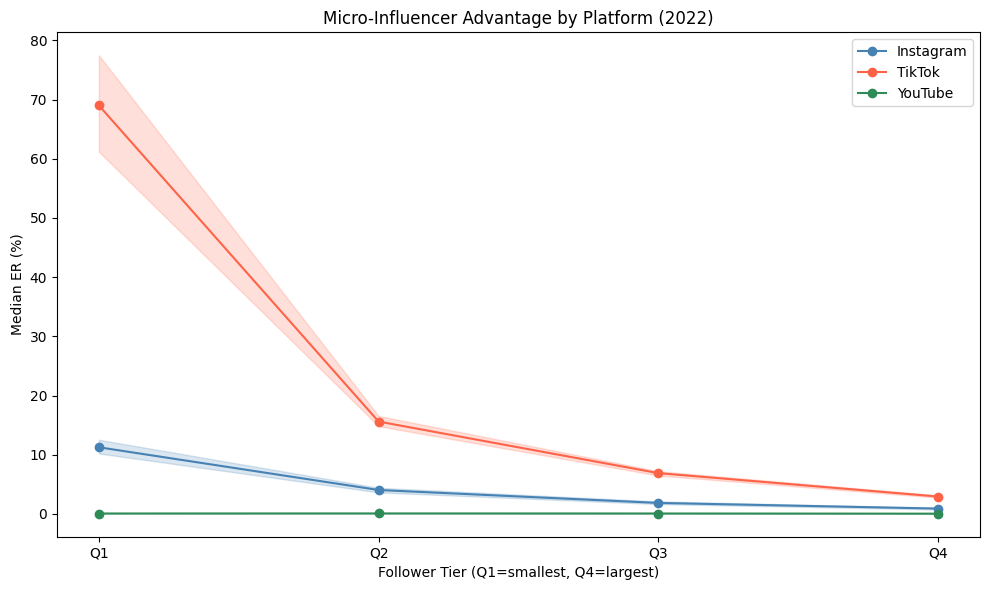

In [110]:
fig, ax = plt.subplots(figsize=(10, 6))

for platform, color in colors.items():
    sub = ci_df[ci_df['platform'] == platform]
    ax.plot(sub['tier'], sub['median'], marker='o', color=color, label=platform)
    ax.fill_between(sub['tier'], sub['lower'], sub['upper'], alpha=0.2, color=color)

ax.set_xlabel('Follower Tier (Q1=smallest, Q4=largest)')
ax.set_ylabel('Median ER (%)')
ax.set_title('Micro-Influencer Advantage by Platform (2022)')
ax.legend()
plt.tight_layout()
plt.savefig('rq3_interaction_plot_2022.png', dpi=150)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_30644\378758955.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = stats.f_oneway(*perm_groups).statistic
c:\Users\user\anaconda3\envs\social_media_analysis\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\user\anaconda3\envs\social_media_analysis\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\user\AppData\Local\Temp\ipykernel_30644\378758955.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = stats.f_oneway(*perm_groups).statistic
c:\Users\user\anaconda3\envs\social_media_analysis\Lib\site-packages\numpy\_core\fromnumeric.py:3824: Runti

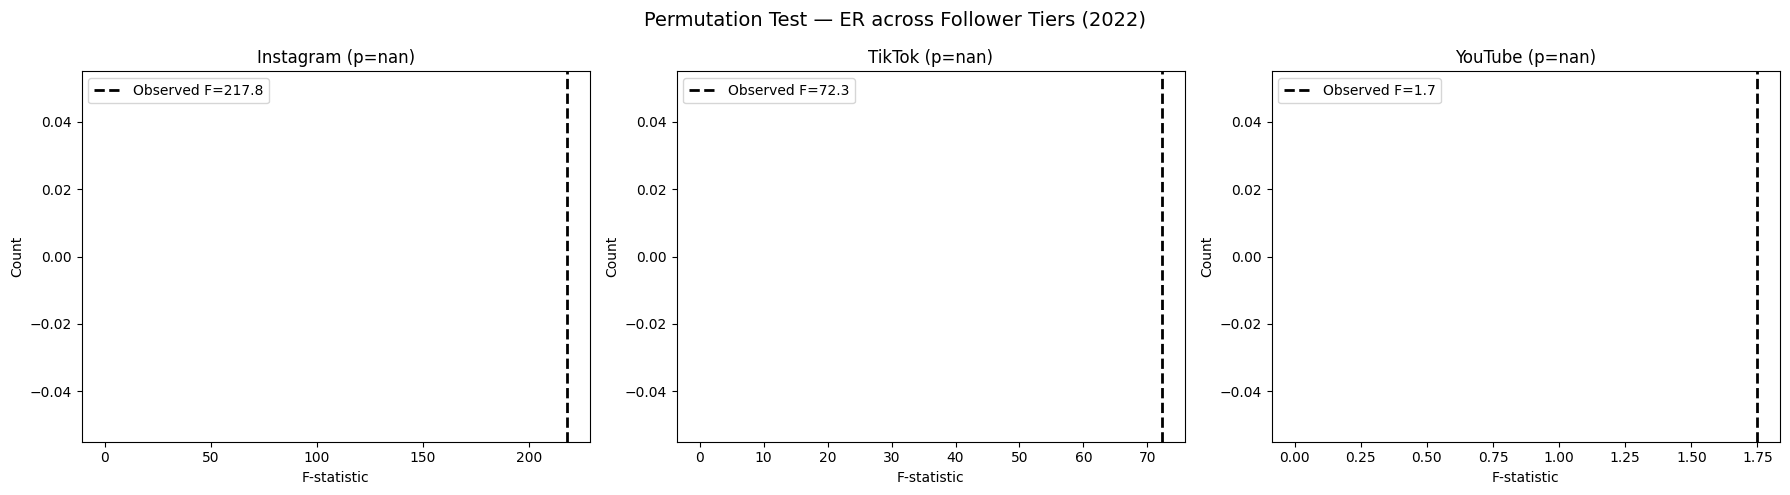

In [113]:
def permutation_f_test_with_dist(data, group_col, value_col, n_perm=10000, random_state=42):
    np.random.seed(random_state)
    groups = [data[data[group_col] == g][value_col].values for g in sorted(data[group_col].unique())]
    observed_f = stats.f_oneway(*groups).statistic
    
    all_values = data[value_col].values
    perm_f = []
    for _ in range(n_perm):
        shuffled = np.random.permutation(all_values)
        perm_groups = np.array_split(shuffled, [len(g) for g in groups[:-1]])
        f = stats.f_oneway(*perm_groups).statistic
        if not np.isnan(f):
            perm_f.append(f)
    
    p_value = np.mean(np.array(perm_f) >= observed_f)
    return observed_f, p_value, perm_f

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, platform, color in zip(axes, ['Instagram', 'TikTok', 'YouTube'], ['steelblue', 'tomato', 'seagreen']):
    sub = rq3_22[rq3_22['platform'] == platform]
    f_obs, p_val, perm_f = permutation_f_test_with_dist(sub, 'tier', 'er_pct')
    ax.hist(perm_f, bins=50, color=color, alpha=0.7)
    ax.axvline(f_obs, color='black', linestyle='--', linewidth=2, label=f'Observed F={f_obs:.1f}')
    ax.set_title(f'{platform} (p={p_val:.4f})')
    ax.set_xlabel('F-statistic')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Permutation Test — ER across Follower Tiers (2022)', fontsize=14)
plt.tight_layout()
plt.savefig('rq3_permutation_test.png', dpi=150)
plt.show()

In [112]:
def permutation_f_test_with_dist(data, group_col, value_col, n_perm=10000, random_state=42):
    np.random.seed(random_state)
    group_labels = sorted(data[group_col].unique())
    groups = [data[data[group_col] == g][value_col].values for g in group_labels]
    group_sizes = [len(g) for g in groups]
    observed_f = stats.f_oneway(*groups).statistic
    
    all_values = data[value_col].values
    perm_f = []
    for _ in range(n_perm):
        shuffled = np.random.permutation(all_values)
        perm_groups = []
        start = 0
        for size in group_sizes:
            perm_groups.append(shuffled[start:start+size])
            start += size
        f = stats.f_oneway(*perm_groups).statistic
        if not np.isnan(f):
            perm_f.append(f)
    
    p_value = np.mean(np.array(perm_f) >= observed_f)
    return observed_f, p_value, perm_f

In [114]:
sub = rq3_22[rq3_22['platform'] == 'Instagram']
f_obs, p_val, perm_f = permutation_f_test_with_dist(sub, 'tier', 'er_pct')
print(f"Observed F: {f_obs}")
print(f"p-value: {p_val}")
print(f"perm_f length: {len(perm_f)}")
print(f"First 10 perm_f: {perm_f[:10]}")

C:\Users\user\AppData\Local\Temp\ipykernel_30644\378758955.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = stats.f_oneway(*perm_groups).statistic


Observed F: 217.7684114672118
p-value: nan
perm_f length: 0
First 10 perm_f: []


c:\Users\user\anaconda3\envs\social_media_analysis\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\user\anaconda3\envs\social_media_analysis\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [115]:
sub = rq3_22[rq3_22['platform'] == 'Instagram']
print(sub['tier'].dtype)
print(sub['er_pct'].dtype)
print(sub[sub['tier']=='Q1']['er_pct'].values[:5])

category
float64
[16.46388889 18.37142857 15.85087719 20.75471698 18.46666667]


In [116]:
rq3_22['tier'] = rq3_22['tier'].astype(str)

sub = rq3_22[rq3_22['platform'] == 'Instagram']
f_obs, p_val, perm_f = permutation_f_test_with_dist(sub, 'tier', 'er_pct')
print(f"Observed F: {f_obs:.3f}")
print(f"perm_f length: {len(perm_f)}")
print(f"First 10: {perm_f[:10]}")

C:\Users\user\AppData\Local\Temp\ipykernel_30644\378758955.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = stats.f_oneway(*perm_groups).statistic


Observed F: 217.768
perm_f length: 0
First 10: []


c:\Users\user\anaconda3\envs\social_media_analysis\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\user\anaconda3\envs\social_media_analysis\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [117]:
sub = rq3_22[rq3_22['platform'] == 'Instagram']
group_labels = sorted(sub['tier'].unique())
groups = [sub[sub['tier'] == g]['er_pct'].values for g in group_labels]
group_sizes = [len(g) for g in groups]
print(f"Group labels: {group_labels}")
print(f"Group sizes: {group_sizes}")

# test one permutation manually
np.random.seed(42)
all_values = sub['er_pct'].values
shuffled = np.random.permutation(all_values)
perm_groups = []
start = 0
for size in group_sizes:
    perm_groups.append(shuffled[start:start+size])
    start += size

print(f"Perm group sizes: {[len(g) for g in perm_groups]}")
print(f"F result: {stats.f_oneway(*perm_groups)}")

Group labels: ['Q1', 'Q2', 'Q3', 'Q4']
Group sizes: [363, 365, 358, 362]
Perm group sizes: [363, 365, 358, 362]
F result: F_onewayResult(statistic=np.float64(0.790404588090689), pvalue=np.float64(0.4992268263512396))


In [118]:
def permutation_f_test_with_dist(data, group_col, value_col, n_perm=10000, random_state=42):
    np.random.seed(random_state)
    group_labels = sorted(data[group_col].unique())
    groups = [data[data[group_col] == g][value_col].values for g in group_labels]
    group_sizes = [len(g) for g in groups]
    observed_f = stats.f_oneway(*groups).statistic
    
    all_values = data[value_col].values
    perm_f = []
    for _ in range(n_perm):
        shuffled = np.random.permutation(all_values)
        start = 0
        perm_groups = []
        for size in group_sizes:
            perm_groups.append(shuffled[start:start+size])
            start += size
        f = stats.f_oneway(*perm_groups).statistic
        if not np.isnan(f):
            perm_f.append(f)
    
    p_value = np.mean(np.array(perm_f) >= observed_f)
    return observed_f, p_value, perm_f

# test
sub = rq3_22[rq3_22['platform'] == 'Instagram']
f_obs, p_val, perm_f = permutation_f_test_with_dist(sub, 'tier', 'er_pct')
print(f"F={f_obs:.3f}, p={p_val:.4f}, n_perm={len(perm_f)}")

F=217.768, p=0.0000, n_perm=10000


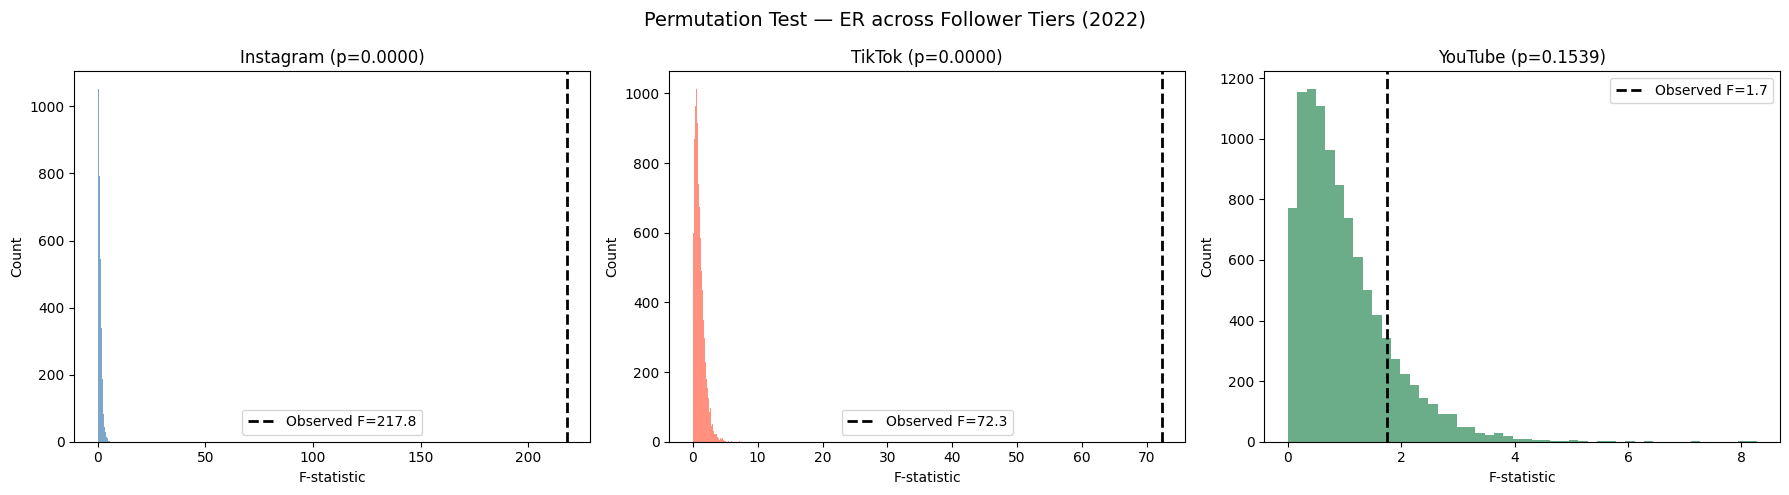

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, platform, color in zip(axes, ['Instagram', 'TikTok', 'YouTube'], ['steelblue', 'tomato', 'seagreen']):
    sub = rq3_22[rq3_22['platform'] == platform]
    f_obs, p_val, perm_f = permutation_f_test_with_dist(sub, 'tier', 'er_pct')
    ax.hist(perm_f, bins=50, color=color, alpha=0.7)
    ax.axvline(f_obs, color='black', linestyle='--', linewidth=2, label=f'Observed F={f_obs:.1f}')
    ax.set_title(f'{platform} (p={p_val:.4f})')
    ax.set_xlabel('F-statistic')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Permutation Test — ER across Follower Tiers (2022)', fontsize=14)
plt.tight_layout()
plt.savefig('rq3_permutation_test.png', dpi=150)
plt.show()

In [120]:
rq3_24 = df24[df24['er_pct'].notna() & df24['followers'].notna() & (df24['er_pct'] > 0)].copy()

for platform in ['Instagram', 'TikTok', 'YouTube']:
    mask = rq3_24['platform'] == platform
    rq3_24.loc[mask, 'tier'] = pd.qcut(
        rq3_24.loc[mask, 'followers'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']
    ).astype(str)

print(rq3_24.groupby(['platform', 'tier'])['er_pct'].median().round(3).unstack())

tier         Q1   Q2    Q3    Q4
platform                        
Instagram  1.38  1.2  0.96  0.89
TikTok     0.20  0.2  0.20  0.30
YouTube    0.60  0.5  0.50  0.50


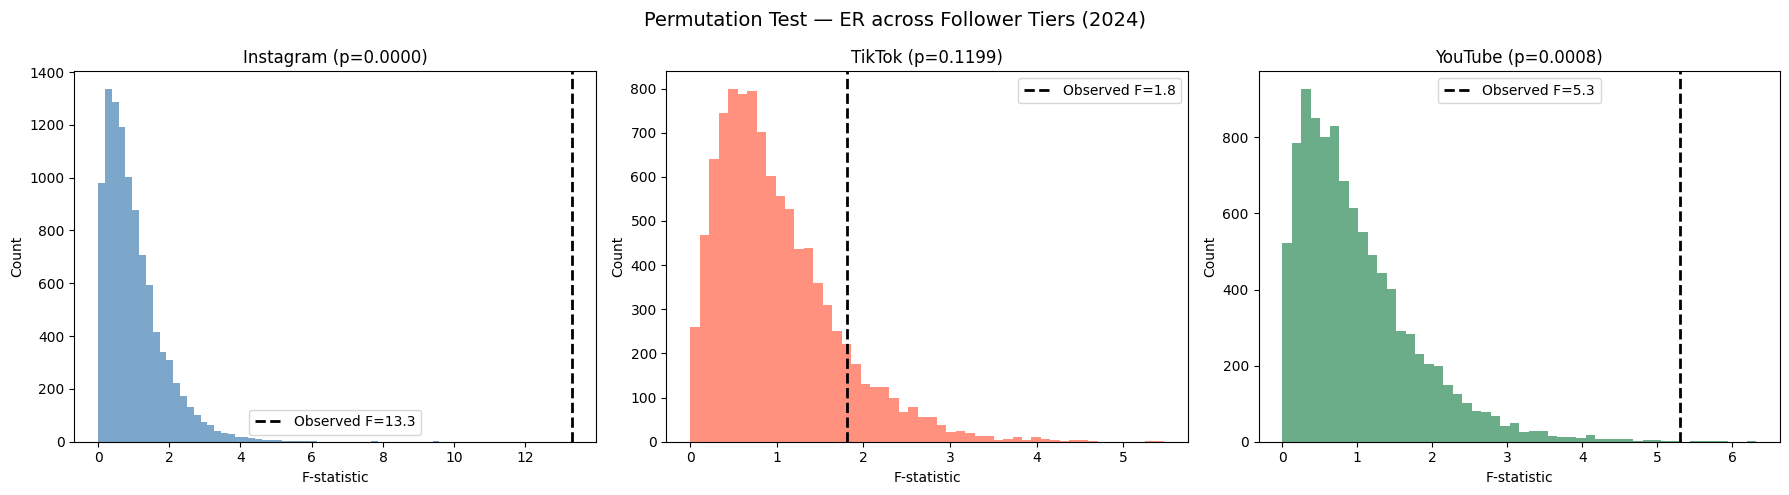

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, platform, color in zip(axes, ['Instagram', 'TikTok', 'YouTube'], ['steelblue', 'tomato', 'seagreen']):
    sub = rq3_24[rq3_24['platform'] == platform]
    f_obs, p_val, perm_f = permutation_f_test_with_dist(sub, 'tier', 'er_pct')
    ax.hist(perm_f, bins=50, color=color, alpha=0.7)
    ax.axvline(f_obs, color='black', linestyle='--', linewidth=2, label=f'Observed F={f_obs:.1f}')
    ax.set_title(f'{platform} (p={p_val:.4f})')
    ax.set_xlabel('F-statistic')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Permutation Test — ER across Follower Tiers (2024)', fontsize=14)
plt.tight_layout()
plt.savefig('rq3_permutation_test_2024.png', dpi=150)
plt.show()

In [122]:
print(rq3_24.groupby(['platform', 'tier']).size().unstack())

tier         Q1    Q2    Q3    Q4
platform                         
Instagram  1367  1410  1327  1363
TikTok      320   319   338   300
YouTube     514   512   512   512


In [123]:
results_24 = []
for platform in ['Instagram', 'TikTok', 'YouTube']:
    for tier in ['Q1', 'Q2', 'Q3', 'Q4']:
        data = rq3_24[(rq3_24['platform'] == platform) & (rq3_24['tier'] == tier)]['er_pct'].values
        median, lower, upper = bootstrap_median_ci(data)
        results_24.append({'platform': platform, 'tier': tier, 'median': median, 'lower': lower, 'upper': upper})

ci_df_24 = pd.DataFrame(results_24)
print(ci_df_24)

     platform tier  median  lower  upper
0   Instagram   Q1    1.38   1.28  1.500
1   Instagram   Q2    1.20   1.10  1.275
2   Instagram   Q3    0.96   0.87  1.060
3   Instagram   Q4    0.89   0.83  0.970
4      TikTok   Q1    0.20   0.20  0.200
5      TikTok   Q2    0.20   0.20  0.200
6      TikTok   Q3    0.20   0.20  0.300
7      TikTok   Q4    0.30   0.30  0.400
8     YouTube   Q1    0.60   0.50  0.800
9     YouTube   Q2    0.50   0.45  0.600
10    YouTube   Q3    0.50   0.40  0.500
11    YouTube   Q4    0.50   0.40  0.600


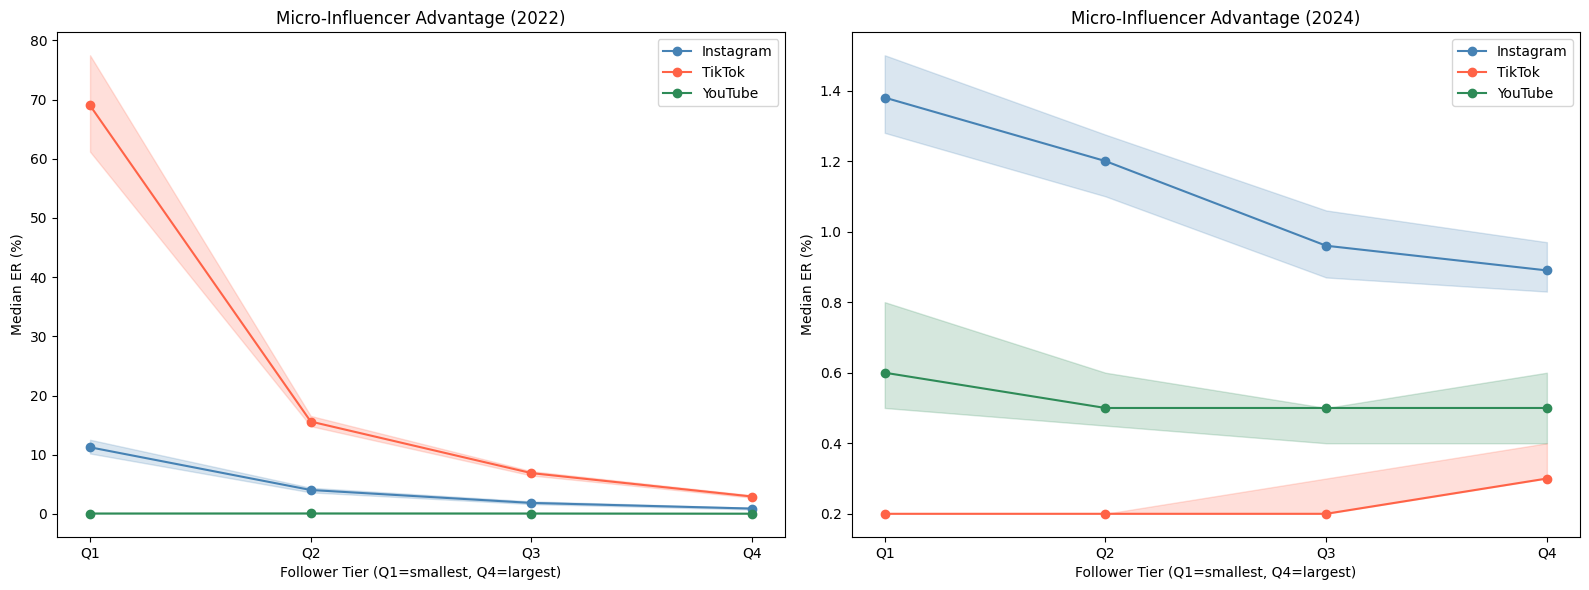

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, ci_df) in zip(axes, [('2022', ci_df), ('2024', ci_df_24)]):
    for platform, color in colors.items():
        sub = ci_df[ci_df['platform'] == platform]
        ax.plot(sub['tier'], sub['median'], marker='o', color=color, label=platform)
        ax.fill_between(sub['tier'], sub['lower'], sub['upper'], alpha=0.2, color=color)
    ax.set_xlabel('Follower Tier (Q1=smallest, Q4=largest)')
    ax.set_ylabel('Median ER (%)')
    ax.set_title(f'Micro-Influencer Advantage ({name})')
    ax.legend()

plt.tight_layout()
plt.savefig('rq3_interaction_comparison.png', dpi=150)
plt.show()

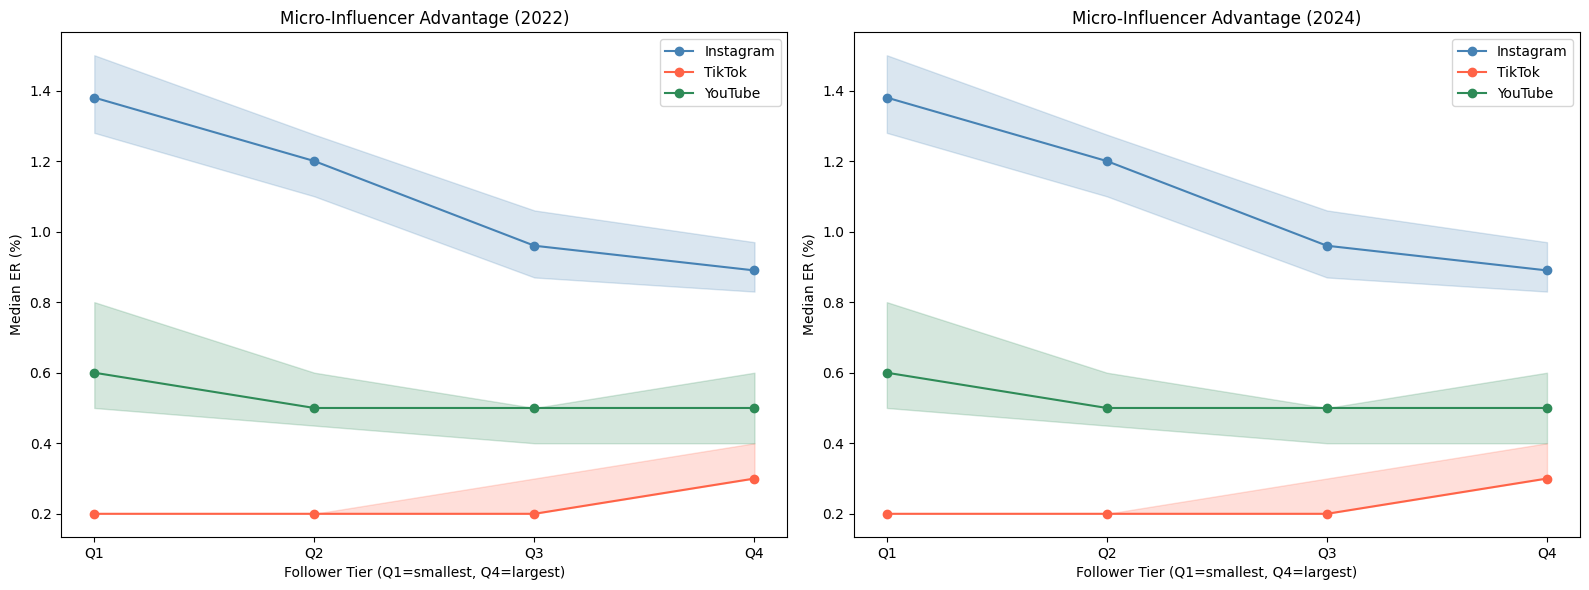

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, ci_df) in zip(axes, [('2022', ci_df), ('2024', ci_df_24)]):
    for platform, color in colors.items():
        sub = ci_df[ci_df['platform'] == platform]
        ax.plot(sub['tier'], sub['median'], marker='o', color=color, label=platform)
        ax.fill_between(sub['tier'], sub['lower'], sub['upper'], alpha=0.2, color=color)
    ax.set_xlabel('Follower Tier (Q1=smallest, Q4=largest)')
    ax.set_ylabel('Median ER (%)')
    ax.set_title(f'Micro-Influencer Advantage ({name})')
    ax.legend()

plt.tight_layout()
plt.savefig('rq3_interaction_comparison.png', dpi=150)
plt.show()

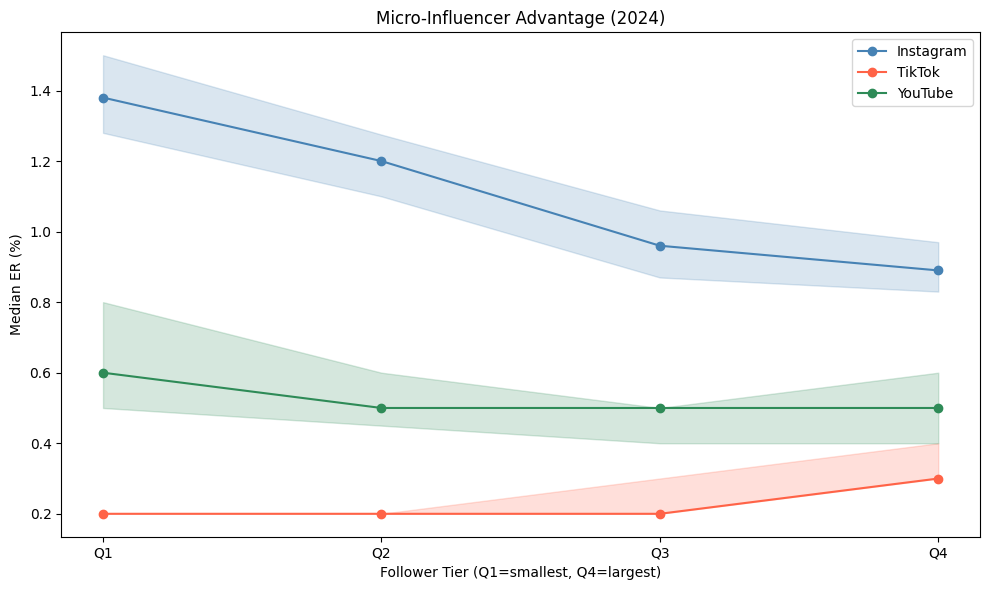

In [126]:
fig, ax = plt.subplots(figsize=(10, 6))

for platform, color in colors.items():
    sub = ci_df_24[ci_df_24['platform'] == platform]
    ax.plot(sub['tier'], sub['median'], marker='o', color=color, label=platform)
    ax.fill_between(sub['tier'], sub['lower'], sub['upper'], alpha=0.2, color=color)

ax.set_xlabel('Follower Tier (Q1=smallest, Q4=largest)')
ax.set_ylabel('Median ER (%)')
ax.set_title('Micro-Influencer Advantage (2024)')
ax.legend()
plt.tight_layout()
plt.savefig('rq3_interaction_2024.png', dpi=150)
plt.show()

In [127]:
def bootstrap_effect_size_diff(data1, data2, n_boot=10000, random_state=42):
    """Bootstrap CI on difference in effect size (Q1 median - Q4 median) between two years"""
    np.random.seed(random_state)
    diffs = []
    for _ in range(n_boot):
        s1 = np.random.choice(data1, size=len(data1), replace=True)
        s2 = np.random.choice(data2, size=len(data2), replace=True)
        diffs.append(np.median(s1) - np.median(s2))
    lower = np.percentile(diffs, 2.5)
    upper = np.percentile(diffs, 97.5)
    observed = np.median(data1) - np.median(data2)
    return observed, lower, upper

print("Effect size (Q1 median ER - Q4 median ER) and change 2022→2024:\n")
for platform in ['Instagram', 'TikTok', 'YouTube']:
    q1_22 = rq3_22[(rq3_22['platform'] == platform) & (rq3_22['tier'] == 'Q1')]['er_pct'].values
    q4_22 = rq3_22[(rq3_22['platform'] == platform) & (rq3_22['tier'] == 'Q4')]['er_pct'].values
    q1_24 = rq3_24[(rq3_24['platform'] == platform) & (rq3_24['tier'] == 'Q1')]['er_pct'].values
    q4_24 = rq3_24[(rq3_24['platform'] == platform) & (rq3_24['tier'] == 'Q4')]['er_pct'].values

    effect_22 = np.median(q1_22) - np.median(q4_22)
    effect_24 = np.median(q1_24) - np.median(q4_24)

    # Bootstrap CI on the difference of effect sizes
    diff_22 = q1_22 - np.median(q4_22)
    diff_24 = q1_24 - np.median(q4_24)
    delta, lower, upper = bootstrap_effect_size_diff(diff_22, diff_24)

    print(f"{platform}:")
    print(f"  Effect size 2022: {effect_22:.3f}%")
    print(f"  Effect size 2024: {effect_24:.3f}%")
    print(f"  Change (2022-2024): {delta:.3f}% [95% CI: {lower:.3f}, {upper:.3f}]")

Effect size (Q1 median ER - Q4 median ER) and change 2022→2024:

Instagram:
  Effect size 2022: 10.356%
  Effect size 2024: 0.490%
  Change (2022-2024): 9.866% [95% CI: 8.801, 11.036]
TikTok:
  Effect size 2022: 66.077%
  Effect size 2024: -0.100%
  Change (2022-2024): 66.177% [95% CI: 58.376, 74.657]
YouTube:
  Effect size 2022: 0.028%
  Effect size 2024: 0.100%
  Change (2022-2024): -0.072% [95% CI: -0.281, 0.025]


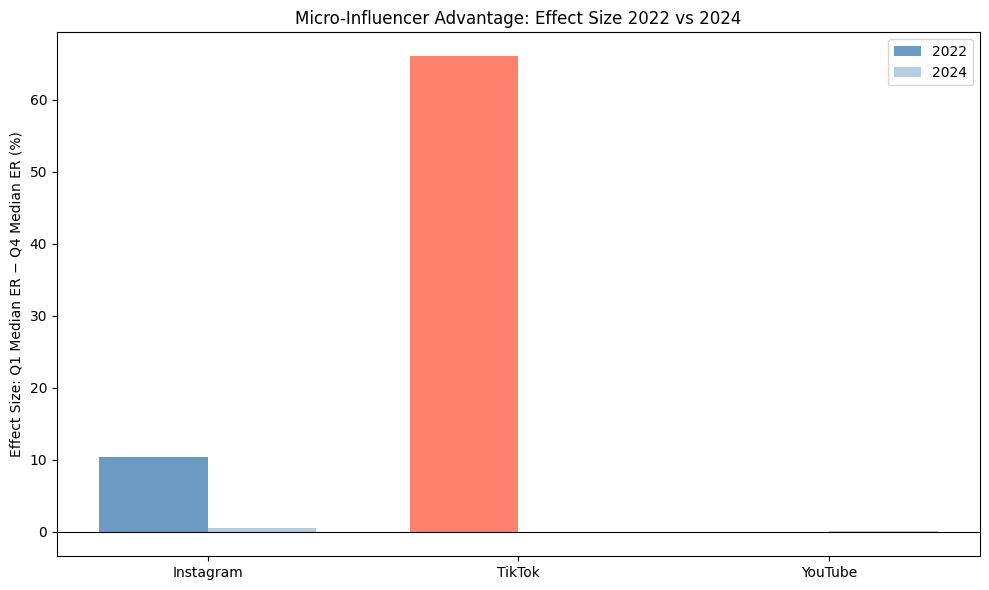

In [128]:
fig, ax = plt.subplots(figsize=(10, 6))

platforms = ['Instagram', 'TikTok', 'YouTube']
effects_22 = [10.356, 66.077, 0.028]
effects_24 = [0.490, -0.100, 0.100]

x = np.arange(len(platforms))
width = 0.35

bars1 = ax.bar(x - width/2, effects_22, width, color=['steelblue', 'tomato', 'seagreen'], alpha=0.8, label='2022')
bars2 = ax.bar(x + width/2, effects_24, width, color=['steelblue', 'tomato', 'seagreen'], alpha=0.4, label='2024')

ax.set_xticks(x)
ax.set_xticklabels(platforms)
ax.set_ylabel('Effect Size: Q1 Median ER − Q4 Median ER (%)')
ax.set_title('Micro-Influencer Advantage: Effect Size 2022 vs 2024')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('rq3_effect_size_comparison.png', dpi=150)
plt.show()

ValueError: 'yerr' must not contain negative values

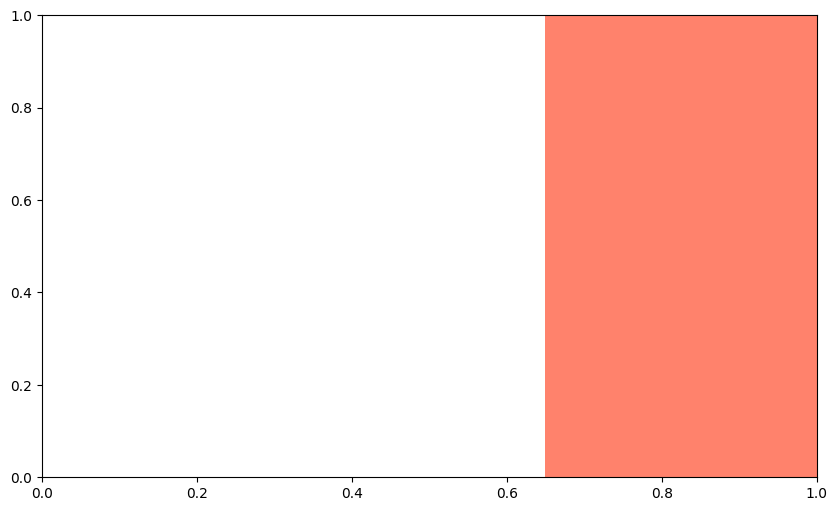

In [135]:
fig, ax = plt.subplots(figsize=(10, 6))

platforms = ['Instagram', 'TikTok', 'YouTube']
effects_22 = [10.356, 66.077, 0.028]
effects_24 = [0.490, -0.100, 0.100]
ci_lower = [8.801, 58.376, -0.281]
ci_upper = [11.036, 74.657, 0.025]
errors = [[e - l for e, l in zip(effects_22, ci_lower)],
          [u - e for e, u in zip(effects_22, ci_upper)]]

x = np.arange(len(platforms))
width = 0.35

ax.bar(x - width/2, effects_22, width, color=['steelblue', 'tomato', 'seagreen'], 
       alpha=0.8, label='2022', yerr=errors, capsize=5)
ax.bar(x + width/2, effects_24, width, color=['steelblue', 'tomato', 'seagreen'], 
       alpha=0.4, label='2024')

ax.set_xticks(x)
ax.set_xticklabels(platforms)
ax.set_ylabel('Effect Size: Q1 Median ER − Q4 Median ER (%)')
ax.set_title('Micro-Influencer Advantage: Effect Size 2022 vs 2024\n(error bars = 95% bootstrap CI on change)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('rq3_effect_size_comparison.png', dpi=150)
plt.show()

ValueError: 'yerr' must not contain negative values

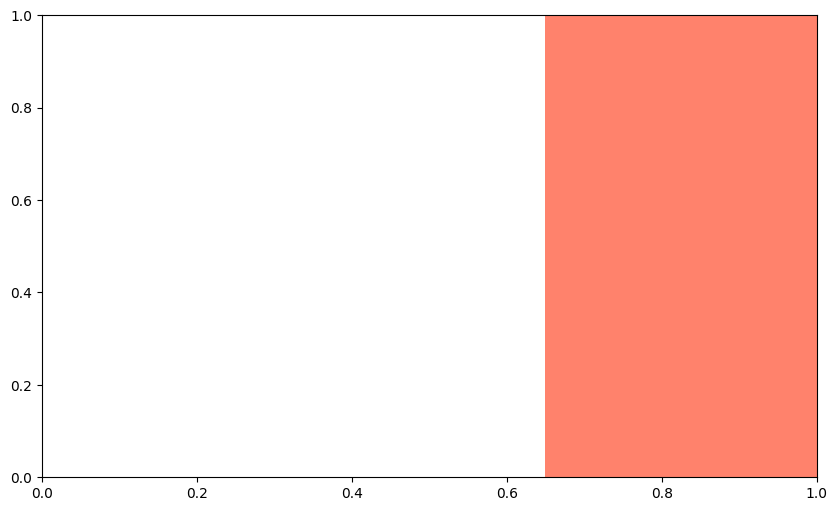

In [134]:
fig, ax = plt.subplots(figsize=(10, 6))

platforms = ['Instagram', 'TikTok', 'YouTube']
effects_22 = [10.356, 66.077, 0.028]
effects_24 = [0.490, -0.100, 0.100]
ci_lower = [8.801, 58.376, -0.281]
ci_upper = [11.036, 74.657, 0.025]

err_low = [e - l for e, l in zip(effects_22, ci_lower)]
err_high = [u - e for u, e in zip(ci_upper, effects_22)]

x = np.arange(len(platforms))
width = 0.35

ax.bar(x - width/2, effects_22, width, color=['steelblue', 'tomato', 'seagreen'],
       alpha=0.8, label='2022', yerr=[err_low, err_high], capsize=5)
ax.bar(x + width/2, effects_24, width, color=['steelblue', 'tomato', 'seagreen'],
       alpha=0.4, label='2024')

ax.set_xticks(x)
ax.set_xticklabels(platforms)
ax.set_ylabel('Effect Size: Q1 Median ER − Q4 Median ER (%)')
ax.set_title('Micro-Influencer Advantage: Effect Size 2022 vs 2024\n(error bars = 95% bootstrap CI on change)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('rq3_effect_size_comparison.png', dpi=150)
plt.show()

In [133]:
err_high = [max(0, u - e) for u, e in zip(ci_upper, effects_22)]
print("err_high fixed:", err_high)

err_high fixed: [0.6799999999999997, 8.579999999999998, 0]


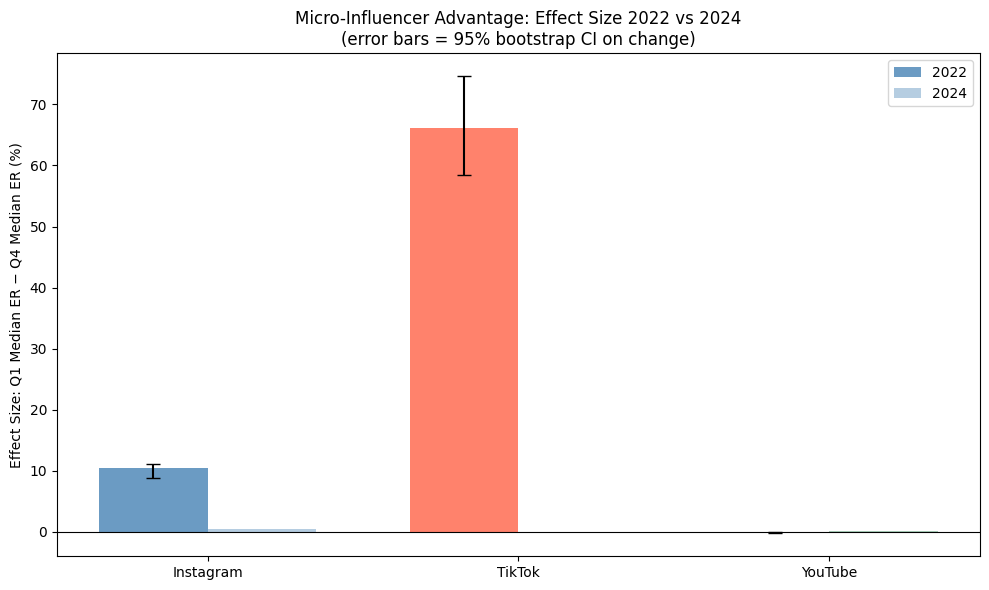

In [136]:
fig, ax = plt.subplots(figsize=(10, 6))

platforms = ['Instagram', 'TikTok', 'YouTube']
effects_22 = [10.356, 66.077, 0.028]
effects_24 = [0.490, -0.100, 0.100]
ci_lower = [8.801, 58.376, -0.281]
ci_upper = [11.036, 74.657, 0.025]

err_low = [e - l for e, l in zip(effects_22, ci_lower)]
err_high = [max(0, u - e) for u, e in zip(ci_upper, effects_22)]

x = np.arange(len(platforms))
width = 0.35

ax.bar(x - width/2, effects_22, width, color=['steelblue', 'tomato', 'seagreen'],
       alpha=0.8, label='2022', yerr=[err_low, err_high], capsize=5)
ax.bar(x + width/2, effects_24, width, color=['steelblue', 'tomato', 'seagreen'],
       alpha=0.4, label='2024')

ax.set_xticks(x)
ax.set_xticklabels(platforms)
ax.set_ylabel('Effect Size: Q1 Median ER − Q4 Median ER (%)')
ax.set_title('Micro-Influencer Advantage: Effect Size 2022 vs 2024\n(error bars = 95% bootstrap CI on change)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('rq3_effect_size_comparison.png', dpi=150)
plt.show()